# Load ERA5-Land Data

In [27]:
# auto reload modified modules
%load_ext autoreload
%autoreload 2
import os
import sys
from pathlib import Path
def _find_repo_root(start):
    for candidate in (start, *start.parents):
        if (candidate / "src").is_dir() and (candidate / "experiments").is_dir():
            return candidate
    return start
CODE_DIR = os.environ.get("ETA_CODE_DIR")
if CODE_DIR is None:
    CODE_DIR = str(_find_repo_root(Path.cwd()))
WORK_DIR = os.environ.get("ETA_WORK_DIR", CODE_DIR)
SRC_DIR = str(Path(CODE_DIR) / "src")
for import_path in (CODE_DIR, SRC_DIR):
    if import_path not in sys.path:
        sys.path.insert(0, import_path)
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from plot_utils import plot_setting, plot_nfields
from utils import *
import torch
import torch.nn as nn
from kde import get_data_pdf
from models import SRCNN
plot_setting()

# Load the cropped data
file_path = WORK_DIR + '/data/era5land_USA_SouthEast_1999-2023_dailymax.nc'
ds = xr.open_dataset(file_path, engine='netcdf4')

# Extract the 'tp' variable (Total Precipitation)
tp = ds['tp']

# Convert to a NumPy array and multiply by 1000 (meter to millimeter)
tp_numpy = tp.values * 1000
# 
# Check if there are any NaN values
has_nan = np.isnan(tp_numpy).any()
# print(f"Contains NaN values: {has_nan}")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


/tmp/ipykernel_1754999/2888810892.py:21: FutureWarning: In a future version, xarray will not decode the variable 'step' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  ds = xr.open_dataset(file_path, engine='netcdf4')


# Downsample Data

In [28]:
# Downsampling by a factor of ds_fact for each spatial dimension
ds_fact = 10
tp_ds_numpy = tp_numpy[:, ::ds_fact, ::ds_fact]  # (9050, 40, 80)

# Data Preprocessing

In [29]:
max_values_original = np.max(tp_numpy, axis=(1, 2))

# max_values_original will have shape (9050,)
print(max_values_original.shape)

# Sort max_values and get the indices that would sort the array
sorted_indices_original = np.argsort(max_values_original)
print(0 in sorted_indices_original)

# Use the sorted_indices to get the sorted max_values
sorted_max_values_original = max_values_original[sorted_indices_original]

# trim the tail
trim_tail_thresh = 240
num_trim_days = len(sorted_max_values_original[sorted_max_values_original > trim_tail_thresh])
trim_days = sorted_indices_original[-num_trim_days:]
sorted_max_values_trim = sorted_max_values_original[:-num_trim_days]
sorted_indices_trim = sorted_indices_original[:-num_trim_days]
print("Trimmed Days: ", trim_days)
print("Trimmed Values: ", sorted_max_values_original[-num_trim_days:])

kept_days = np.delete(np.arange(len(tp_numpy)), trim_days)
tp_trim_numpy = tp_numpy[kept_days]
tp_trim_ds_numpy = tp_ds_numpy[kept_days]
tp_trim_tensor = torch.tensor(tp_trim_numpy)
tp_trim_ds_tensor = torch.tensor(tp_trim_ds_numpy)
print(tp_trim_ds_tensor.shape)
print(tp_trim_tensor.shape)

(9050,)
True
Trimmed Days:  [3533 4611 4610 3534 6353 6354]
Trimmed Values:  [264.42355 265.57224 265.57224 272.9087  404.68246 406.81866]
torch.Size([9044, 8, 16])
torch.Size([9044, 80, 160])


# Select Training Data

In [30]:
import torch.optim as optim
from rich.progress import Progress
from torch.utils.data import DataLoader, TensorDataset
from copy import deepcopy
import os
import gc

# Convert numpy arrays to PyTorch tensors and move to GPU
tp_trim_ds_tensor = torch.tensor(tp_trim_ds_numpy, dtype=torch.float32).unsqueeze(1).to(device)  # Add channel dimension
tp_trim_tensor = torch.tensor(tp_trim_numpy, dtype=torch.float32).unsqueeze(1).to(device)  # Full-resolution target

# Use 20% of the data (5 years) for training
num_years = 0.5
portion = num_years/25
train_size = int(portion * len(tp_trim_ds_tensor))
train_input = tp_trim_ds_tensor[:train_size]
train_target = tp_trim_tensor[:train_size]

# use full data to select the best MSE model for baseline comparison
test_input = deepcopy(tp_trim_ds_tensor)
test_target = deepcopy(tp_trim_tensor)

# move data to device
train_input = train_input.to(device)
train_target = train_target.to(device)
test_input = test_input.to(device)
test_target = test_target.to(device)

# Create DataLoader for batch processing
batch_size = 64
train_dataset = TensorDataset(train_input, train_target)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_dataset = TensorDataset(test_input, test_target)
test_loader = DataLoader(test_dataset, batch_size=25*batch_size, shuffle=False)

print(train_input.shape)
print(train_target.shape)
print(test_input.shape)
print(test_target.shape)

torch.Size([180, 1, 8, 16])
torch.Size([180, 1, 80, 160])
torch.Size([9044, 1, 8, 16])
torch.Size([9044, 1, 80, 160])


# Start Training MSE

In [31]:
# MSE training disabled for command-line reruns; pretrained checkpoint is loaded in the next cell.
# seed = 43
# torch.manual_seed(seed)
# torch.cuda.manual_seed_all(seed)
#
# Initialize CNN model, optimizer, and loss function
# model_mse = SRCNN(hidden_dim=64, num_blocks=3, scale_factor=ds_fact)
#
# Move model and data to multiple GPUs
# model_mse = nn.DataParallel(model_mse)  # Use all available GPUs
# model_mse.to(device)
#
# optimizer and loss
# optimizer = optim.Adam(model_mse.parameters(), lr=3e-4)
# scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=200, gamma=.2)
# mse_loss = nn.MSELoss()
#
# Training settings
# num_epochs = 500
# grad_clip = 1
#
# Checkpoint
# save_mse = False
# best_loss = float('inf')
# save_dir = WORK_DIR + "/models/precip-srcnn/"
# os.makedirs(save_dir, exist_ok=True)
# model_mse_filename = f"srcnn-mse-{num_years}yr-{ds_fact}ds.pth"
# save_path_mse = os.path.join(save_dir, model_mse_filename)
# print(save_path_mse)
#
# with Progress() as progress:
#     print("Training Started")
#     epoch_task = progress.add_task("Training Epochs", total=num_epochs)
#
#     for epoch in range(num_epochs):
#         running_train_loss = 0.0
#         running_test_loss = 0.0
#         # Progress bar for each epoch
#         # batch_task = progress.add_task(f"Epoch {epoch+1}/{num_epochs}", total=len(train_loader))
#
#         model_mse.train()
#         for batch_idx, (input_data, target) in enumerate(train_loader):
#             model_mse.train()
#
#             # Zero the gradients
#             optimizer.zero_grad()
#
#             # Forward pass
#             output = model_mse(input_data)
#
#             # Compute loss
#             loss = mse_loss(output, target)
#
#             # Backward pass
#             loss.backward()
#
#             # Update weights
#             optimizer.step()
#
#             # Update loss
#             running_train_loss += loss.item()
#
#         epoch_train_loss = running_train_loss/len(train_loader)
#         scheduler.step()
#
#         model_mse.eval()
#         with torch.no_grad():
#             for _, (test_in, test_tar) in enumerate(test_loader):
#                 test_output = model_mse(test_in)
#                 loss = mse_loss(test_output, test_tar)
#                 running_test_loss += loss.item()
#
#             epoch_test_loss = running_test_loss/len(test_loader)
#             if epoch_test_loss < best_loss:
#                 best_loss = epoch_test_loss
#                 if save_mse:
#                     torch.save(model_mse.state_dict(), save_path_mse)
#
#         # Update epoch progress bar
#         progress.update(epoch_task, advance=1)
#         progress.console.print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {epoch_train_loss:.6f}, Best Val Loss: {best_loss:.6f}")#, Average Upsample Loss : {upsample_loss/len(train_loader):.6f}")


# Load Trained MSE Model (If Applicable)

In [32]:
# load path
load_dir = WORK_DIR + "/models/precip-srcnn/"
os.makedirs(load_dir, exist_ok=True)

# model name
model_mse_filename = f"srcnn-mse-{num_years}yr-{ds_fact}ds.pth"
print(model_mse_filename)
# save model
load_path = os.path.join(load_dir, model_mse_filename)

# load model
model_mse = SRCNN(hidden_dim=64, num_blocks=3, scale_factor=ds_fact)
model_mse = nn.DataParallel(model_mse)
model_mse.load_state_dict(torch.load(load_path))
model_mse.to(device)
print()

srcnn-mse-0.5yr-10ds.pth



# Run MSE-Model on Trimmed Dataset

In [33]:
from test_utils import test_model_mse
test_dataset = TensorDataset(test_input, test_target)
test_loader = DataLoader(test_dataset, batch_size=50*batch_size, shuffle=False)

full_output_mse, test_mse_loss_mse = test_model_mse(model_mse, test_loader)
print(full_output_mse.shape)
print("MSE Test Loss:", test_mse_loss_mse)

(9044, 80, 160)
MSE Test Loss: 8.361367225646973


# MSE Output PDF

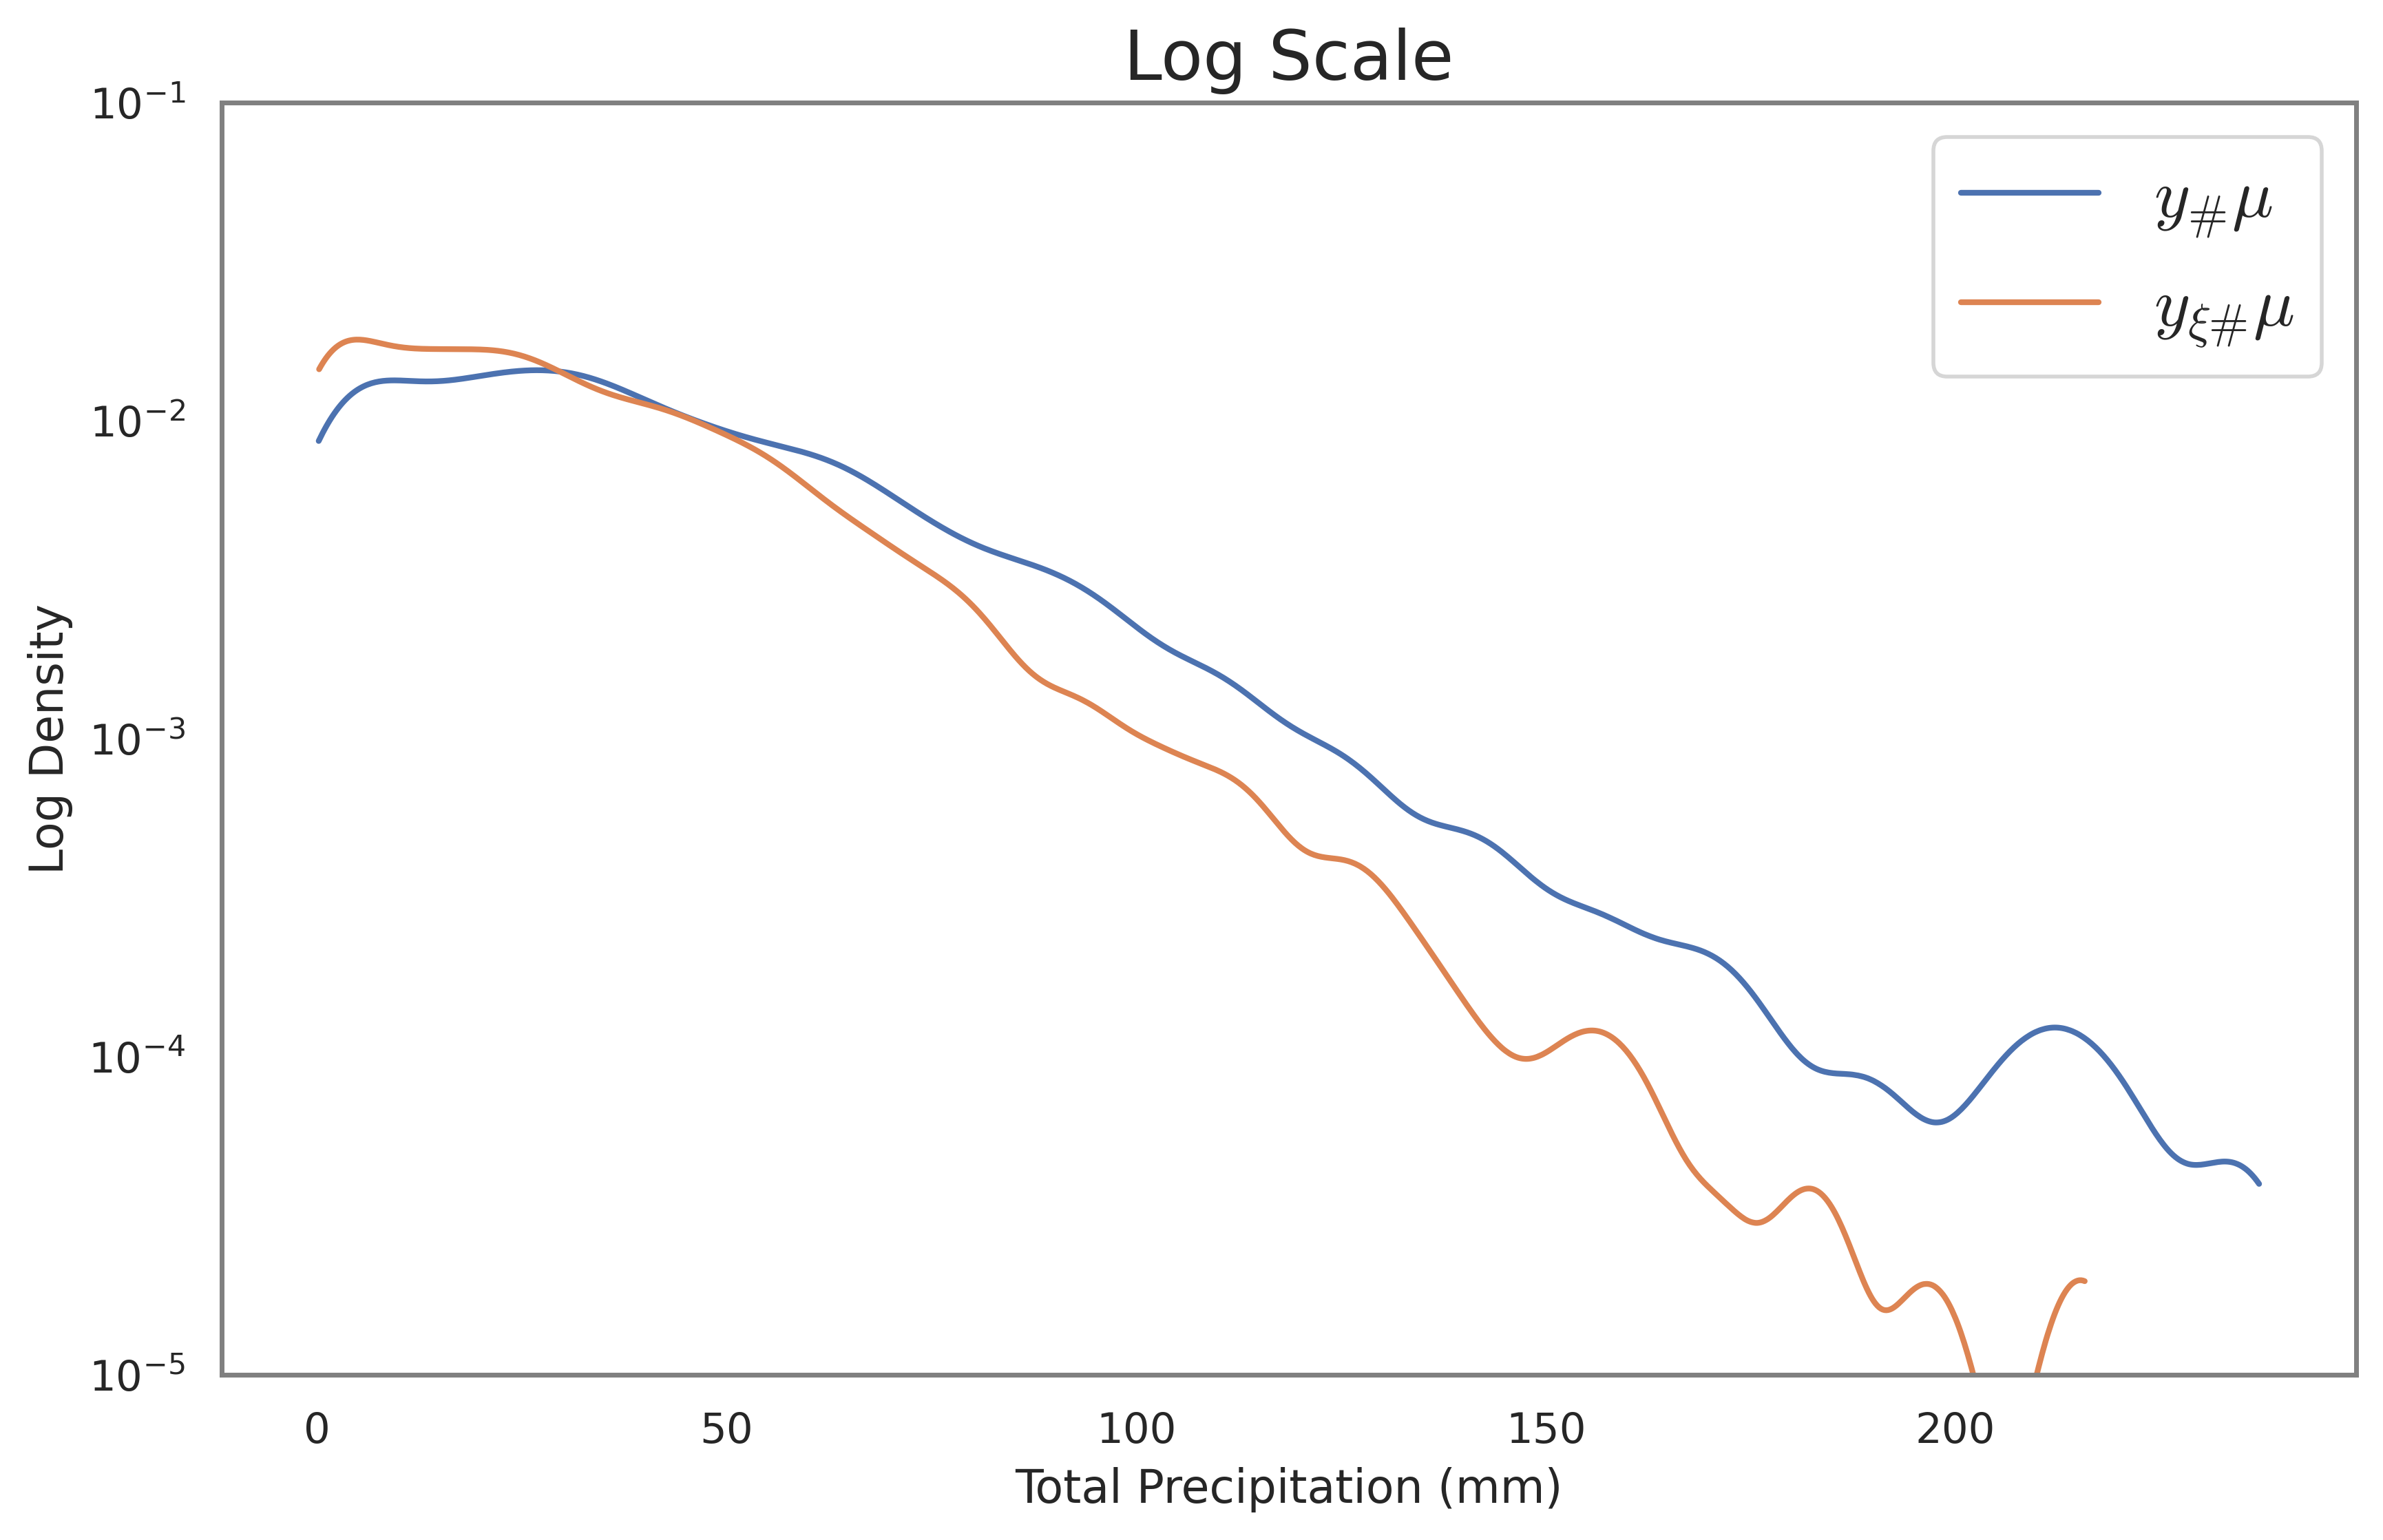

In [34]:
max_values = np.max(tp_trim_numpy, axis=(1, 2))
max_values_mse = np.max(full_output_mse, axis=(1,2))
y_eval_tp, py_tp, _ = get_data_pdf(data=torch.tensor(max_values), data_all=torch.tensor(max_values))
y_eval_tp_mse, py_tp_mse, _ = get_data_pdf(data=torch.tensor(max_values_mse), data_all=torch.tensor(max_values_mse))

# Plotting the two KDEs for comparison
plt.figure(figsize=(10, 6), dpi=400)

# Plot the KDE for the original data
plt.plot(y_eval_tp, py_tp, label=r"$y_\#\mu$")
# plt.plot(y_eval_tp_train, py_tp_train, label="5 Years True")
plt.plot(y_eval_tp_mse, py_tp_mse, label=r"$y_{\xi\#}\mu$")

# Add plot labels and title
plt.xlabel("Total Precipitation (mm)")
plt.ylabel("Log Density")
plt.title("Log Scale", fontsize=18)
plt.ylim(1e-5,1e-1)
plt.yscale('log')
plt.legend(prop={'size':18})

# Fit EVD

Parameters of GEV: **shape** $k$, **location** $\mu$, and **scale** $\sigma > 0$
$$f(x; k, \mu, \sigma) = \frac{1}{\sigma} \left(1 + k \frac{x - \mu}{\sigma}\right)^{-(1 + \frac{1}{k})} \exp\left(-\left(1 + k \frac{x - \mu}{\sigma}\right)^{-1/k}\right)$$

1. **Gumbel Distribution** ($k = 0$):
   $$
   f(x; \mu, \sigma) = \frac{1}{\sigma} \exp\left(-\frac{x - \mu}{\sigma} - \exp\left(-\frac{x - \mu}{\sigma}\right)\right)
   $$

2. **Frechet Distribution** ($k > 0$): Heavy-tailed.

3. **Weibull Distribution** ($k < 0$): Bounded upper tail.

In [35]:
from scipy.stats import genextreme
from scipy.integrate import quad

def fit_gev_with_cutoff(data, cutoff):
    """
    Fits a Generalized Extreme Value (GEV) distribution to the given 1D data,
    with a cutoff applied. All values greater than the cutoff are ignored,
    and the density is normalized.

    Parameters:
        data (array-like): The 1D data array to which the GEV distribution is fitted.
        cutoff (float): The cutoff value. Data values above this are ignored.

    Returns:
        dict: A dictionary containing the shape, location, scale parameters,
              and additional information about the fitting process.
    """
    # Filter the data based on the cutoff
    filtered_data = data[data <= cutoff]

    # Ensure filtered data is not empty
    if len(filtered_data) == 0:
        raise ValueError("No data points are below the cutoff.")

    # Fit the GEV distribution to the filtered data
    shape, loc, scale = genextreme.fit(filtered_data)
    
    scale = scale + 4 # manually lift up the tail a bit
    normalization_constant = quad(
                            lambda t: genextreme.pdf(t, shape, loc=loc, scale=scale),
                            -np.inf, cutoff)[0]

    # Define the normalized PDF with cutoff
    def normalized_pdf(x):
        raw_pdf = genextreme.pdf(x, shape, loc=loc, scale=scale)
        return raw_pdf / normalization_constant
    
    x = np.linspace(min(filtered_data), cutoff, len(data))
    pdf = np.array([normalized_pdf(val) for val in x])

    # Results as a dictionary
    results = {
        "shape": shape,
        "location": loc,
        "scale": scale,
        "cutoff": cutoff,
        "c": normalization_constant,
        "x": x,
        "pdf": pdf
    }

    return results

cutoff_value = np.ceil(max(max_values)) + 20
fit_results = fit_gev_with_cutoff(max_values, cutoff=cutoff_value)

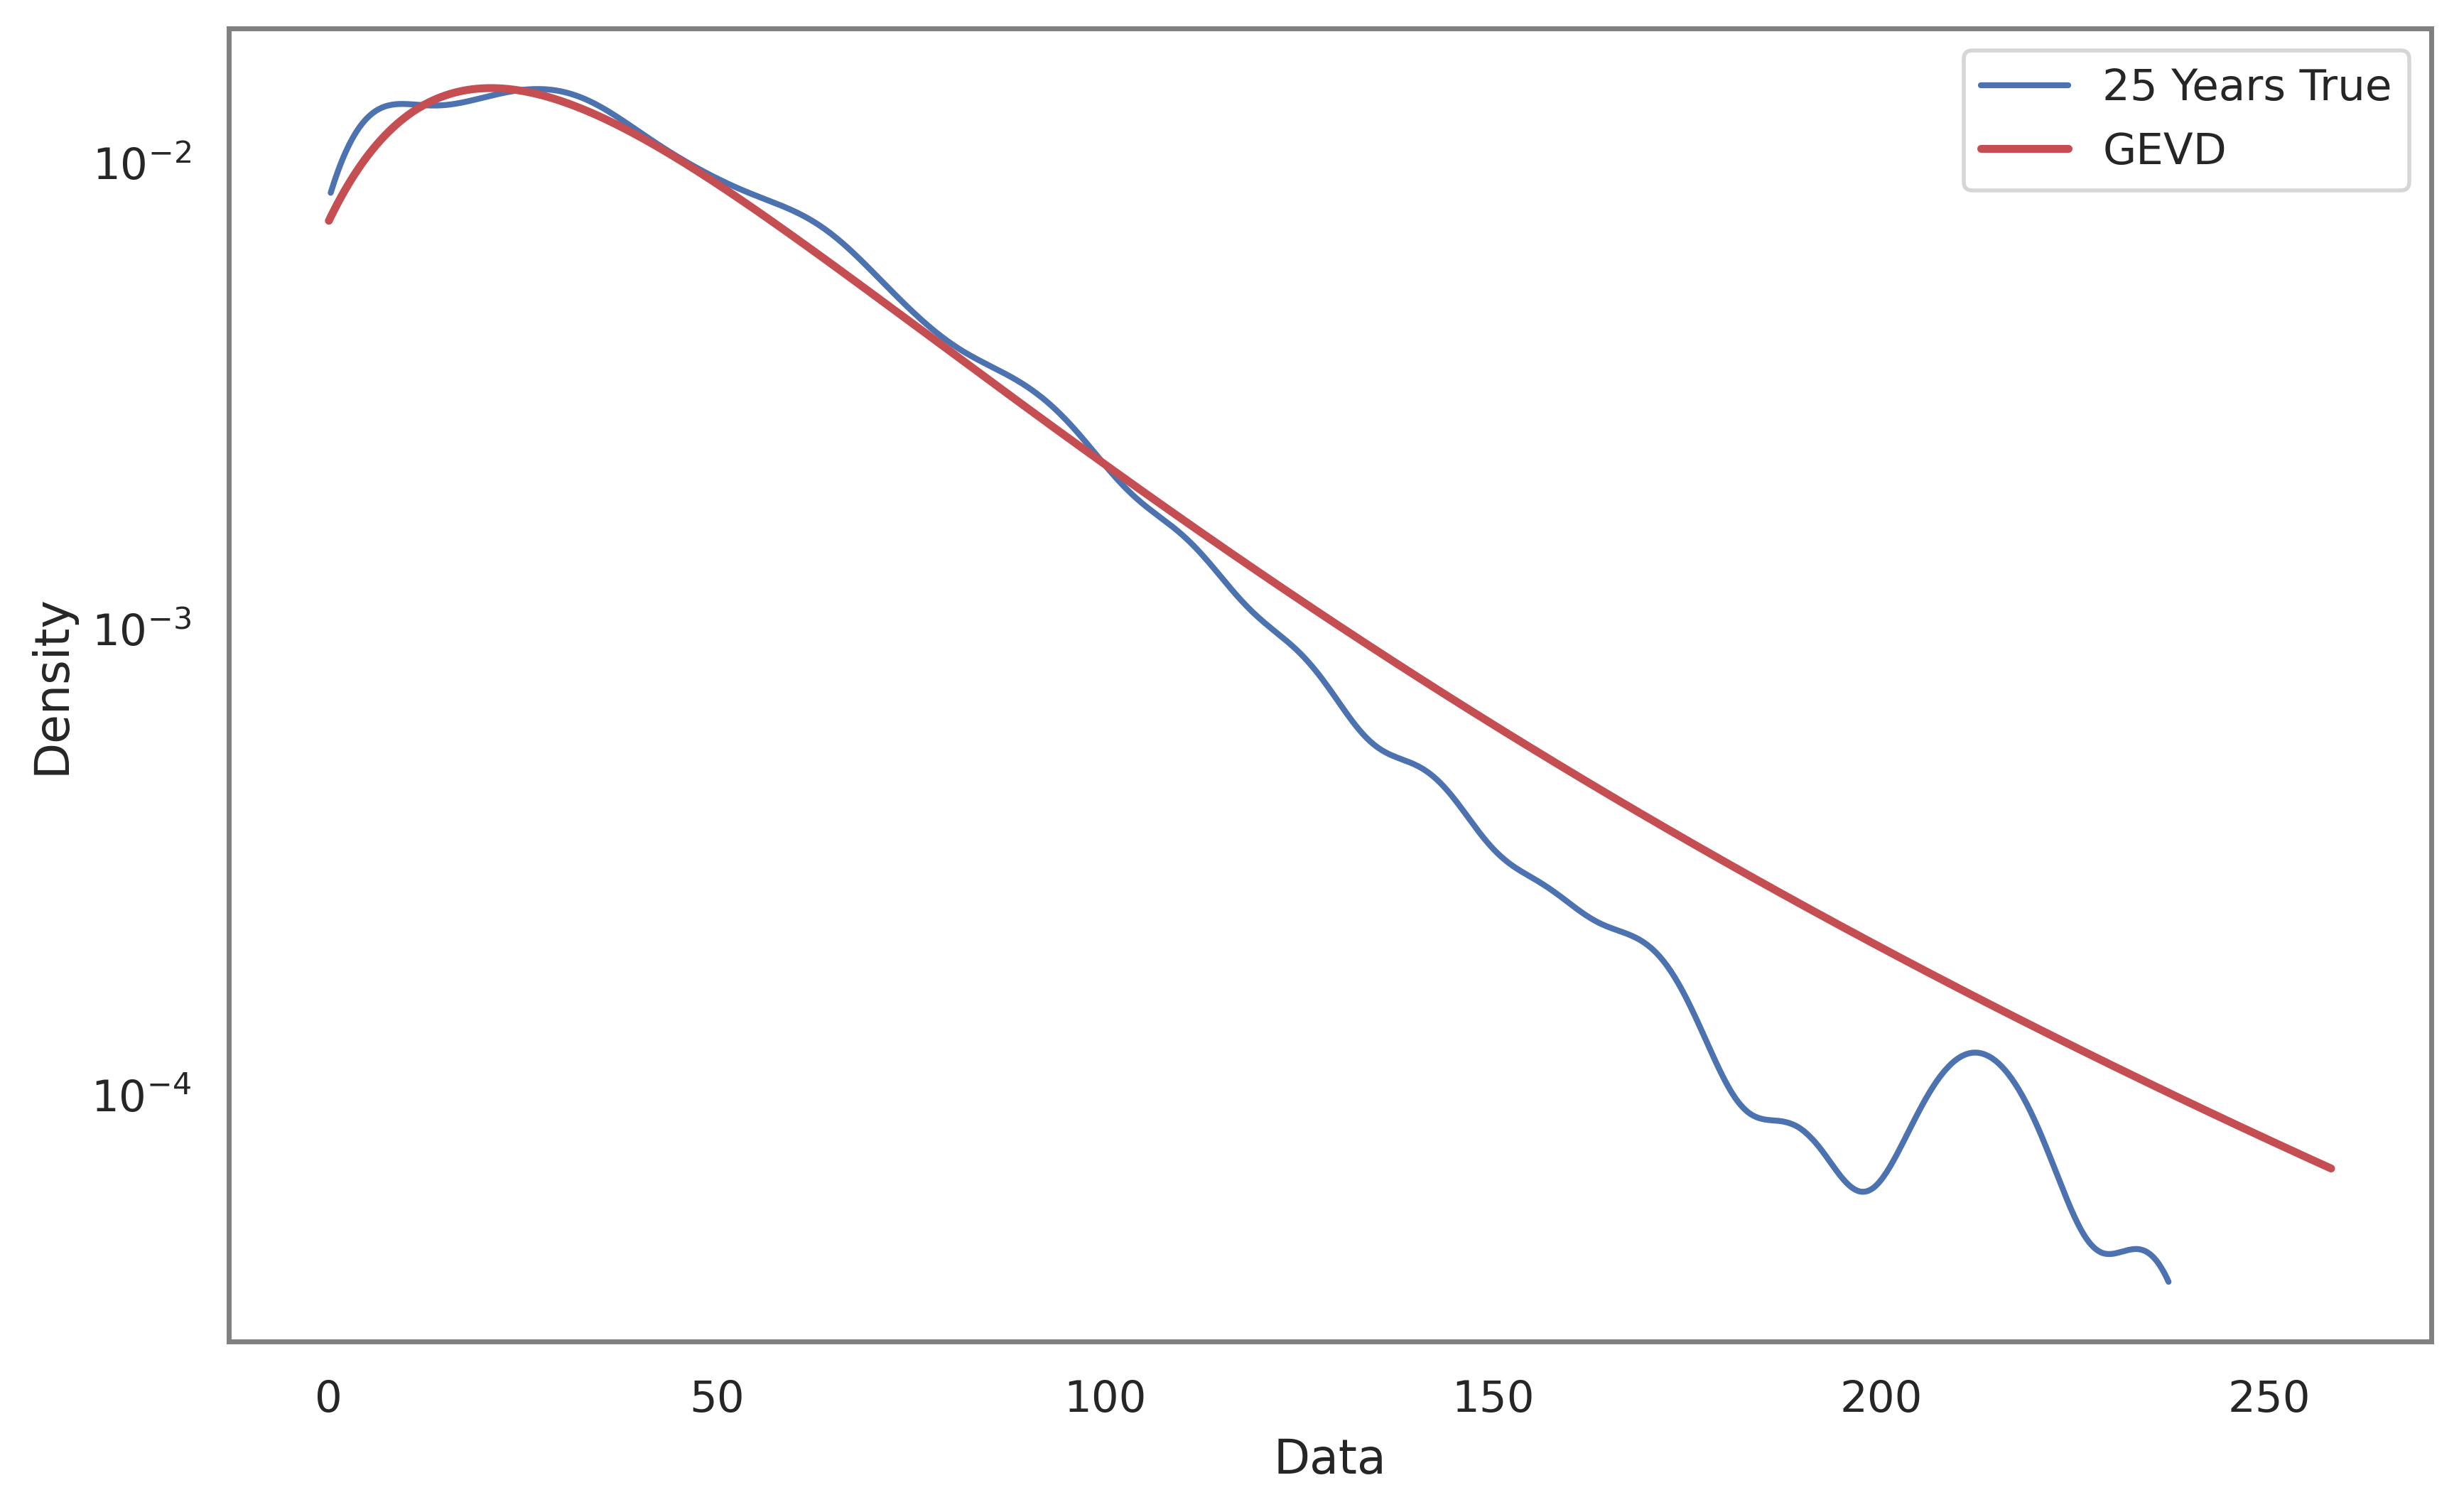

In [36]:
plt.figure(figsize=(10, 6), dpi=400)
# plt.hist(max_values, bins=40, density=True, alpha=0.4, color="gray", label="25 Years True")
# plt.plot(x, pdf, "r-", lw=2, label="Normalized GEV PDF")
plt.plot(y_eval_tp, py_tp, label="25 Years True")
plt.plot(fit_results['x'], fit_results['pdf'], "r-", lw=2, label="GEVD")
plt.xlabel("Data")
plt.ylabel("Density")
plt.yscale('log')
plt.legend()

plt.show()

# Quantile Estimation
$$Q(p ; \mu, \sigma, k)= \begin{cases}\mu-\sigma \ln (-\ln p) & \text { for } k=0 \text { and } p \in(0,1) \\ \mu+\frac{\sigma}{k}\left((-\ln p)^{-k}-1\right) & \text { for } k>0 \text { and } p \in[0,1), \text { or } k<0 \text { and } p \in(0,1] ;\end{cases}$$

In [37]:
tau = 0.95 # quantile
y_tau = genextreme.ppf(tau*fit_results['c'], fit_results['shape'], fit_results['location'], fit_results['scale'])
Qy = lambda q : genextreme.ppf(q*fit_results['c'], fit_results['shape'], fit_results['location'], fit_results['scale'])
gamma = 1- fit_results['c']

print(y_tau)
print(gamma)
print(fit_results['cutoff'])
print(fit_results['shape'])
print(fit_results['scale'])

122.83570750509358
0.004696358286656821
258.0
-0.17868831075604058
25.928067249254624


# ETA with W1 Loss

In [38]:
# tail threshold, equivalent to \tau in the paper
w1_tail_thresh = y_tau

# sort max values
max_values = np.max(tp_trim_numpy, axis=(1,2))
sorted_indices = np.argsort(max_values)
sorted_max_values = max_values[sorted_indices]

# get tail that defines w1
# num_w1_days = len(sorted_max_values[sorted_max_values > w1_tail_thresh])
num_w1_days = 350
w1_truedays = sorted_indices[-num_w1_days:]

quantiles = torch.linspace(tau, 1, num_w1_days)
w1_truemax = torch.tensor([Qy(q) for q in quantiles])
print(w1_truemax)

def get_fixed_days_max_pos(full_output: np.ndarray, w1_days):
    """
    helper function - get the location index of the tail values 
    
    input:
        - selected days: 
        
    """
    max_indices = np.argmax(full_output.reshape(full_output.shape[0], -1), axis=1)
    max_pos_row, max_pos_col = np.unravel_index(max_indices, (80,160))
    max_pos = np.stack([np.arange(full_output.shape[0]), max_pos_row, max_pos_col], axis=1).T
    
    num_w1_days = len(w1_days)
    fixed_days_max_pos = torch.tensor(max_pos[:,w1_days])
    fixed_days_max_pos = torch.cat((torch.arange(num_w1_days).reshape(1,-1), fixed_days_max_pos[1:,:]), dim=0)
    fixed_days_max_pos.requires_grad = False
    
    return fixed_days_max_pos

def get_max_time_pos(full_output : np.ndarray, num_w1_days):
    """
    helper function - get the time and location index of the tail values 
    
    input:
        - full_output: output of model running on the entire testing dataset
        - num_w1_days: number of tail days taken, equivalent to n_q (number of 
                       pre-determined quantile levels) in the paper
    """
    # get w1_days
    max_values_output = np.max(full_output, axis=(1,2))
    sorted_indices_output = np.argsort(max_values_output)
    w1_days = sorted_indices_output[-num_w1_days:]
    
    # get w1_max_pos
    max_indices = np.argmax(full_output.reshape(full_output.shape[0], -1), axis=1)
    max_pos_row, max_pos_col = np.unravel_index(max_indices, (80,160))
    max_pos = np.stack([np.arange(full_output.shape[0]), max_pos_row, max_pos_col], axis=1).T
    w1_max_pos = torch.tensor(max_pos[:,w1_days])
    w1_max_pos = torch.cat((torch.arange(num_w1_days).reshape(1,-1), w1_max_pos[1:,:]), dim=0)
    w1_max_pos.requires_grad = False
    
    return w1_days, w1_max_pos
    

# def get_w1_objects_dynamic_days():
#     pass

# w1_truedays_max_pos = get_fixed_days_max_pos(full_output_mse, w1_truedays)
# w1_days, w1_max_pos = get_max_time_pos(full_output_mse, num_w1_days)
print(num_w1_days)

tensor([122.8357, 122.9527, 123.0701, 123.1879, 123.3060, 123.4245, 123.5433,
        123.6625, 123.7821, 123.9021, 124.0223, 124.1430, 124.2641, 124.3855,
        124.5074, 124.6295, 124.7522, 124.8751, 124.9985, 125.1223, 125.2464,
        125.3710, 125.4959, 125.6213, 125.7471, 125.8732, 125.9998, 126.1268,
        126.2542, 126.3820, 126.5103, 126.6389, 126.7680, 126.8975, 127.0275,
        127.1579, 127.2887, 127.4199, 127.5516, 127.6837, 127.8164, 127.9494,
        128.0828, 128.2168, 128.3512, 128.4861, 128.6214, 128.7572, 128.8934,
        129.0302, 129.1674, 129.3051, 129.4433, 129.5819, 129.7211, 129.8607,
        130.0008, 130.1415, 130.2827, 130.4243, 130.5664, 130.7091, 130.8523,
        130.9960, 131.1402, 131.2850, 131.4302, 131.5760, 131.7224, 131.8693,
        132.0167, 132.1647, 132.3133, 132.4624, 132.6120, 132.7622, 132.9131,
        133.0644, 133.2163, 133.3688, 133.5220, 133.6757, 133.8299, 133.9849,
        134.1404, 134.2964, 134.4532, 134.6105, 134.7684, 134.92

In [39]:
def get_w1_input(w1_days):
    """
    function to get w1 loss input
    """
    w1_input = tp_trim_ds_numpy[w1_days]
    w1_input = torch.tensor(w1_input).unsqueeze(1)
    return w1_input
    
num_mse_years = num_years
mse_portion = num_mse_years/25
mse_size = int(mse_portion * len(tp_trim_ds_tensor))
mse_input = tp_trim_ds_tensor[:mse_size]
mse_target = tp_trim_tensor[:mse_size]

print(mse_input.shape)
print(mse_target.shape)

# move data to device
w1_truemax = w1_truemax.to(device)
mse_input = mse_input.to(device)
mse_target = mse_target.to(device)

torch.Size([180, 1, 8, 16])
torch.Size([180, 1, 80, 160])


# ETA Testing Function

In [40]:
def test_model_eta(model, TestLoader, 
                   w1_loss, w1_input, w1_truemax, w1_max_pos, 
                   device=None):
    """
    run model on TestLoader and report the MSE loss and the W1 loss
    
    return:
        - full_output: squeezed numpy array with dimension (N,...)
        - test_loss_mse: mean squared error on TestLoader
    
    """
    if not device:
        device = next(model.parameters()).device
    model.to(device)
    model.eval()
    _, sample_target = next(iter(TestLoader))
    full_output = torch.zeros_like(sample_target[0]).cpu()
    mse_loss = nn.MSELoss()
    running_test_mse_loss = 0.0
    
    with torch.no_grad():
        for _, (test_in, test_tar) in enumerate(test_loader):
            test_in, test_tar = test_in.to(device), test_tar.to(device)  
            test_output = model(test_in).detach()
            loss = mse_loss(test_output, test_tar)
            running_test_mse_loss += loss.item()
            full_output = torch.cat((full_output,test_output.squeeze().cpu()),dim=0)
    test_mse_loss = running_test_mse_loss/len(test_loader)
    
    # when testing, should record the true tail values
    num_w1_days = len(w1_truemax)
    full_output = full_output[1:].numpy()
    max_values_output = np.max(full_output, axis=(1,2))
    sorted_indices_output = np.argsort(max_values_output)
    sorted_max_values_output = max_values_output[sorted_indices_output]
    w1_max_test = torch.tensor(sorted_max_values_output[-num_w1_days:])
    w1_max_test = w1_max_test.to(w1_truemax.device)
    
#     w1_output_test = model(w1_input).squeeze()
#     w1_max_test = w1_output_test[tuple(w1_max_pos)]
    w1_loss_test = w1_loss(w1_max_test, w1_truemax).item()
    
    return full_output, test_mse_loss, w1_loss_test

def get_max_indices_vals(full_output : np.ndarray, num_w1_days):
    max_values_output = np.max(full_output, axis=(1,2))
    sorted_indices_output = np.argsort(max_values_output)
    sorted_max_values_output = max_values_output[sorted_indices_output]
    max_indices = sorted_indices_output[-num_w1_days:]
    max_vals = torch.tensor(sorted_max_values_output[-num_w1_days:])
    return max_indices, max_vals

# ETA Training Function

In [41]:
def train_model_eta(model_eta, test_loader, 
                    seed, num_epochs,
                    mse_input, mse_target,
                    w1_loss, w1_truemax, w1_truedays,
                    lambd_, omega:int, varying_days:bool,
                    save_checkpoint=True, save_path=None,
                    scheduler=None, clip_gradient=False,
                    device=None):
    """
    Training function of \eta-learning
    
    Inputs:
        - model_eta: pretrained model with MSE
        - lambd_: loss balancing parameter
        - omega: window size 
    
    """
    
    global_seed(seed)
    if not device:
        device = next(model_eta.parameters()).device
    
    if save_checkpoint and not save_path:
        raise ValueError("No Path to Save Model!")
    
    # define mse_loss
    mse_loss = nn.MSELoss()
    
    # move data to device
    w1_truemax = w1_truemax.to(device)
    mse_input = mse_input.to(device)
    mse_target = mse_target.to(device)
    
    # for checkpoint use
    best_mse_loss = float('inf')
    best_w1_loss = float('inf')
    best_total_loss = float('inf')
    
    # record training loss history
    train_mse_loss_hist = []
    train_w1_loss_hist = []
    test_mse_loss_hist = []
    test_w1_loss_hist = []
    
    # get initialization of w1_days + w1_max_pos
    num_w1_days = len(w1_truedays)
    full_output_eta, _ = test_model_mse(model_eta, test_loader)
    w1_days = None
    if varying_days:
        w1_days, w1_max_pos = get_max_time_pos(full_output_eta, num_w1_days)
    else:
        w1_max_pos = get_fixed_days_max_pos(full_output_eta, w1_truedays)
        w1_days = w1_truedays
    w1_input = get_w1_input(w1_days)
    
    with Progress() as progress:
        epoch_task = progress.add_task("Training Epochs", total=num_epochs)

        for epoch in range(num_epochs):
            # could add minibatch training, but no need for this test case
            model_eta.train()

            # Zero the gradients
            optimizer.zero_grad()
            
            # get w1_input, move to device
            if varying_days:
                w1_input = get_w1_input(w1_days)
            w1_input = w1_input.to(device)
            
            # Forward pass
            mse_output = model_eta(mse_input)
            w1_output = model_eta(w1_input).squeeze()
            # Implements main Eq. (12): evaluate g(u)=max(u) at IICT indices.
            w1_max = w1_output[tuple(w1_max_pos)]

            # Compute loss
            mse_loss_val = mse_loss(mse_output, mse_target)
            w1_loss_val = w1_loss(w1_max, w1_truemax)
            
            # Implements main Eq. (14): supervised MSE plus lambda-weighted observable W1 penalty.
            loss = mse_loss_val + lambd_ * w1_loss_val
            loss.backward()

            # Gradient clipping
            if clip_gradient:
                torch.nn.utils.clip_grad_norm_(model_eta.parameters(), grad_clip)

            # Update weights
            optimizer.step()
            if scheduler:
                scheduler.step()
            
            # Run inference on more inputs
            full_output_eta, test_mse_loss_eta, w1_loss_test = test_model_eta(
                model_eta,
                test_loader,
                w1_loss,
                w1_input,
                w1_truemax,
                w1_max_pos,
                device=device
            )
            
            # update w1_max_pos whenever window size is reached
            if (epoch+1)%omega == 0:
                if varying_days:
                    w1_days, w1_max_pos = get_max_time_pos(full_output_eta, num_w1_days)
                else:
                    # here, w1_days = w1_truedays
                    w1_max_pos = get_fixed_days_max_pos(full_output_eta, w1_days)

            # save best w1 loss model
            if w1_loss_test < best_w1_loss:
                best_w1_loss = w1_loss_test
                best_mse_loss = test_mse_loss_eta
                if save_checkpoint:
                    torch.save(model_eta.state_dict(), save_path)

            # save loss history
            train_mse_loss_hist.append(mse_loss_val)
            train_w1_loss_hist.append(w1_loss_val)
            test_mse_loss_hist.append(test_mse_loss_eta)
            test_w1_loss_hist.append(w1_loss_test)
            
            # Update epoch progress bar; print every 25 epochs and always print the final epoch.
            progress.update(epoch_task, advance=1)
            if ((epoch + 1) % 25 == 0) or ((epoch + 1) == num_epochs):
                progress.console.print(
                    f"Epoch {epoch+1}/{num_epochs}, "
#                   f"Best MSE Test Loss: {best_mse_loss:.6f}, "
#                   f"Best W1 Test Loss: {best_w1_loss:.6f}, "
#                   f"Curr W1 Test Loss: {w1_loss_test:.6f}"
                    f"Best MSE: {best_mse_loss:.6f}, "
                    f"Best W1: {best_w1_loss:.6f}, "
                    f"Curr W1: {w1_loss_test:.6f}, "
                )
#             progress.console.print(f"Epoch {epoch+1}/{num_epochs}, Best MSE Test Loss: {best_mse_loss:.6f}, Best W1 Test Loss: {best_w1_loss:.6f}")
    
    loss_dict = {
        "train_mse" : train_mse_loss_hist,
        "train_w1" : train_w1_loss_hist,
        "test_mse" : test_mse_loss_hist,
        "test_w1" : test_w1_loss_hist
    }
    
    return model_eta, loss_dict

In [42]:
# training components
seed = 43
global_seed(seed)
model_eta = deepcopy(model_mse).to(device)
num_epochs = 150
optimizer = optim.Adam(model_eta.parameters(), lr=3e-4)
# Implements main Methods Eq. (13): mean absolute difference between scalar observable quantiles.
w1_loss = lambda x,y: torch.abs(x-y).mean()
lambd_ = 1.
omega = 1 # window size
varying_days = True
test_dataset = TensorDataset(test_input, test_target)
test_loader = DataLoader(test_dataset, batch_size=50*batch_size, shuffle=False)

# training techniques
# scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=.6)
# clip_gradient = False

# checkpoint
save_eta = True
best_mse_loss = float('inf')
best_w1_loss = float('inf')
best_total_loss = float('inf')
save_dir = WORK_DIR + "/models/precip-srcnn/"
os.makedirs(save_dir, exist_ok=True)
model_eta_filename = f"srcnn-eta-gevd-{num_years}yr-{ds_fact}ds-{int(w1_tail_thresh)}tail-{omega}omega.pth"
save_path_eta = os.path.join(save_dir, model_eta_filename)
print(save_path_eta)

/path/to/eta/models/precip-srcnn/srcnn-eta-gevd-0.5yr-10ds-122tail-1omega.pth


In [43]:
# model_eta, loss_dict_eta = train_model_eta(
#     model_eta, 
#     test_loader, 
#     seed,
#     num_epochs,
#     mse_input, 
#     mse_target,
#     w1_loss, 
#     w1_truemax, 
#     w1_truedays,
#     lambd_, 
#     omega, 
#     varying_days,
#     save_checkpoint=save_eta, 
#     save_path=save_path_eta
# #     scheduler=scheduler, 
# #     clip_gradient=clip_gradient,
# )

# Run ETA on Full Dataset

In [44]:
test_dataset = TensorDataset(test_input, test_target)
test_loader = DataLoader(test_dataset, batch_size=25*batch_size, shuffle=False)

omega=1
w1_tail_thresh = w1_tail_thresh
save_dir = WORK_DIR + "/models/precip-srcnn/"
load_path_eta = os.path.join(save_dir, f"srcnn-eta-gevd-{num_years}yr-{ds_fact}ds-{int(w1_tail_thresh)}tail-{omega}omega.pth")
print(load_path_eta)
# device = "cuda:0"
# model_eta = CorrectNet(model_mse, scale_factor=ds_fact, kernel_size=3, padding=1)
model_eta = SRCNN(hidden_dim=64, num_blocks=3, scale_factor=ds_fact)
model_eta = nn.DataParallel(model_eta)
model_eta.load_state_dict(torch.load(load_path_eta))
model_eta.to(device)
full_output_eta, test_mse_loss_eta, w1_loss_test = test_model_eta(
    model_eta,
    test_loader,
    w1_loss,
    None,
    w1_truemax,
    None,
    device=device
)

print(full_output_eta.shape)
print("ETA MSE Test Loss:", test_mse_loss_eta)
print("ETA W1 Test Loss:", w1_loss_test)

/path/to/eta/models/precip-srcnn/srcnn-eta-gevd-0.5yr-10ds-122tail-1omega.pth
(9044, 80, 160)
ETA MSE Test Loss: 10.80391534169515
ETA W1 Test Loss: 0.5844018855814646


In [45]:
def get_max_indices_values(full_output : np.ndarray, num_w1_days):
    max_values_output = np.max(full_output, axis=(1,2))
    sorted_indices_output = np.argsort(max_values_output)
    sorted_max_values_output = max_values_output[sorted_indices_output]
    max_value_indices = sorted_indices_output[-num_w1_days:]
    max_values = torch.tensor(sorted_max_values_output[-num_w1_days:])
    return max_value_indices, max_values

max_value_indices_eta, max_values_eta = get_max_indices_values(full_output_eta, num_w1_days)
print(max_value_indices_eta)
print(w1_truedays)
print(max_values_eta)

[3541 8233 8232 8236  271 2460 7340 8920 1014 6727   21 7596 8529 1974
 7119 8235 4917 2849 8530 2049 2848 4140 3859 4971 7101 6941 6588 1975
 4481 4855 4608 3435 7368 8315 5541 8873 3909 5607 6939 7597  193 7413
 3910 8921 2511 4177 3932 5242 6539 3781 3382 2822 3737 7828 7849 6195
 3381 7414   29  115 8192 5354 3170 8872 8314 6114 1018 7136 4918 7137
 7848 3169  777 6705 1017 5542 3434 8394 4471 8562 7100 1193 2133 5099
 5876 1194 2510 5379 1322 4176 6589 6538 7497  778  492 1586 7842 6706
 2359  632 3533 6245 3499 7376 1889 3500 1363 1702 2890 1366 3153 5098
 6350 6489  116 5928 7498 7851 3157 3630 3158 3513 2891 7686 4470 3933
 5875 3509 4482 2078 6580 6058 8087 8086 7685 5241 3154 8612 6488 3928
 7054 8032 7055  123 3927  124 1379 4475  520   28 5927 3511 4178 2360
 5220 8395 4805 5219 8033 1378 2676 3904 7850 7213 6730 3178 7827 2921
 6106 2920 6696 2675 6661 2378 7214 4474 4972 6581 5197  283 2379 6105
 4247 3349 5198 4478 1890 3350  976 1013 6057 1062 3583  694 7594 6659
 7117 

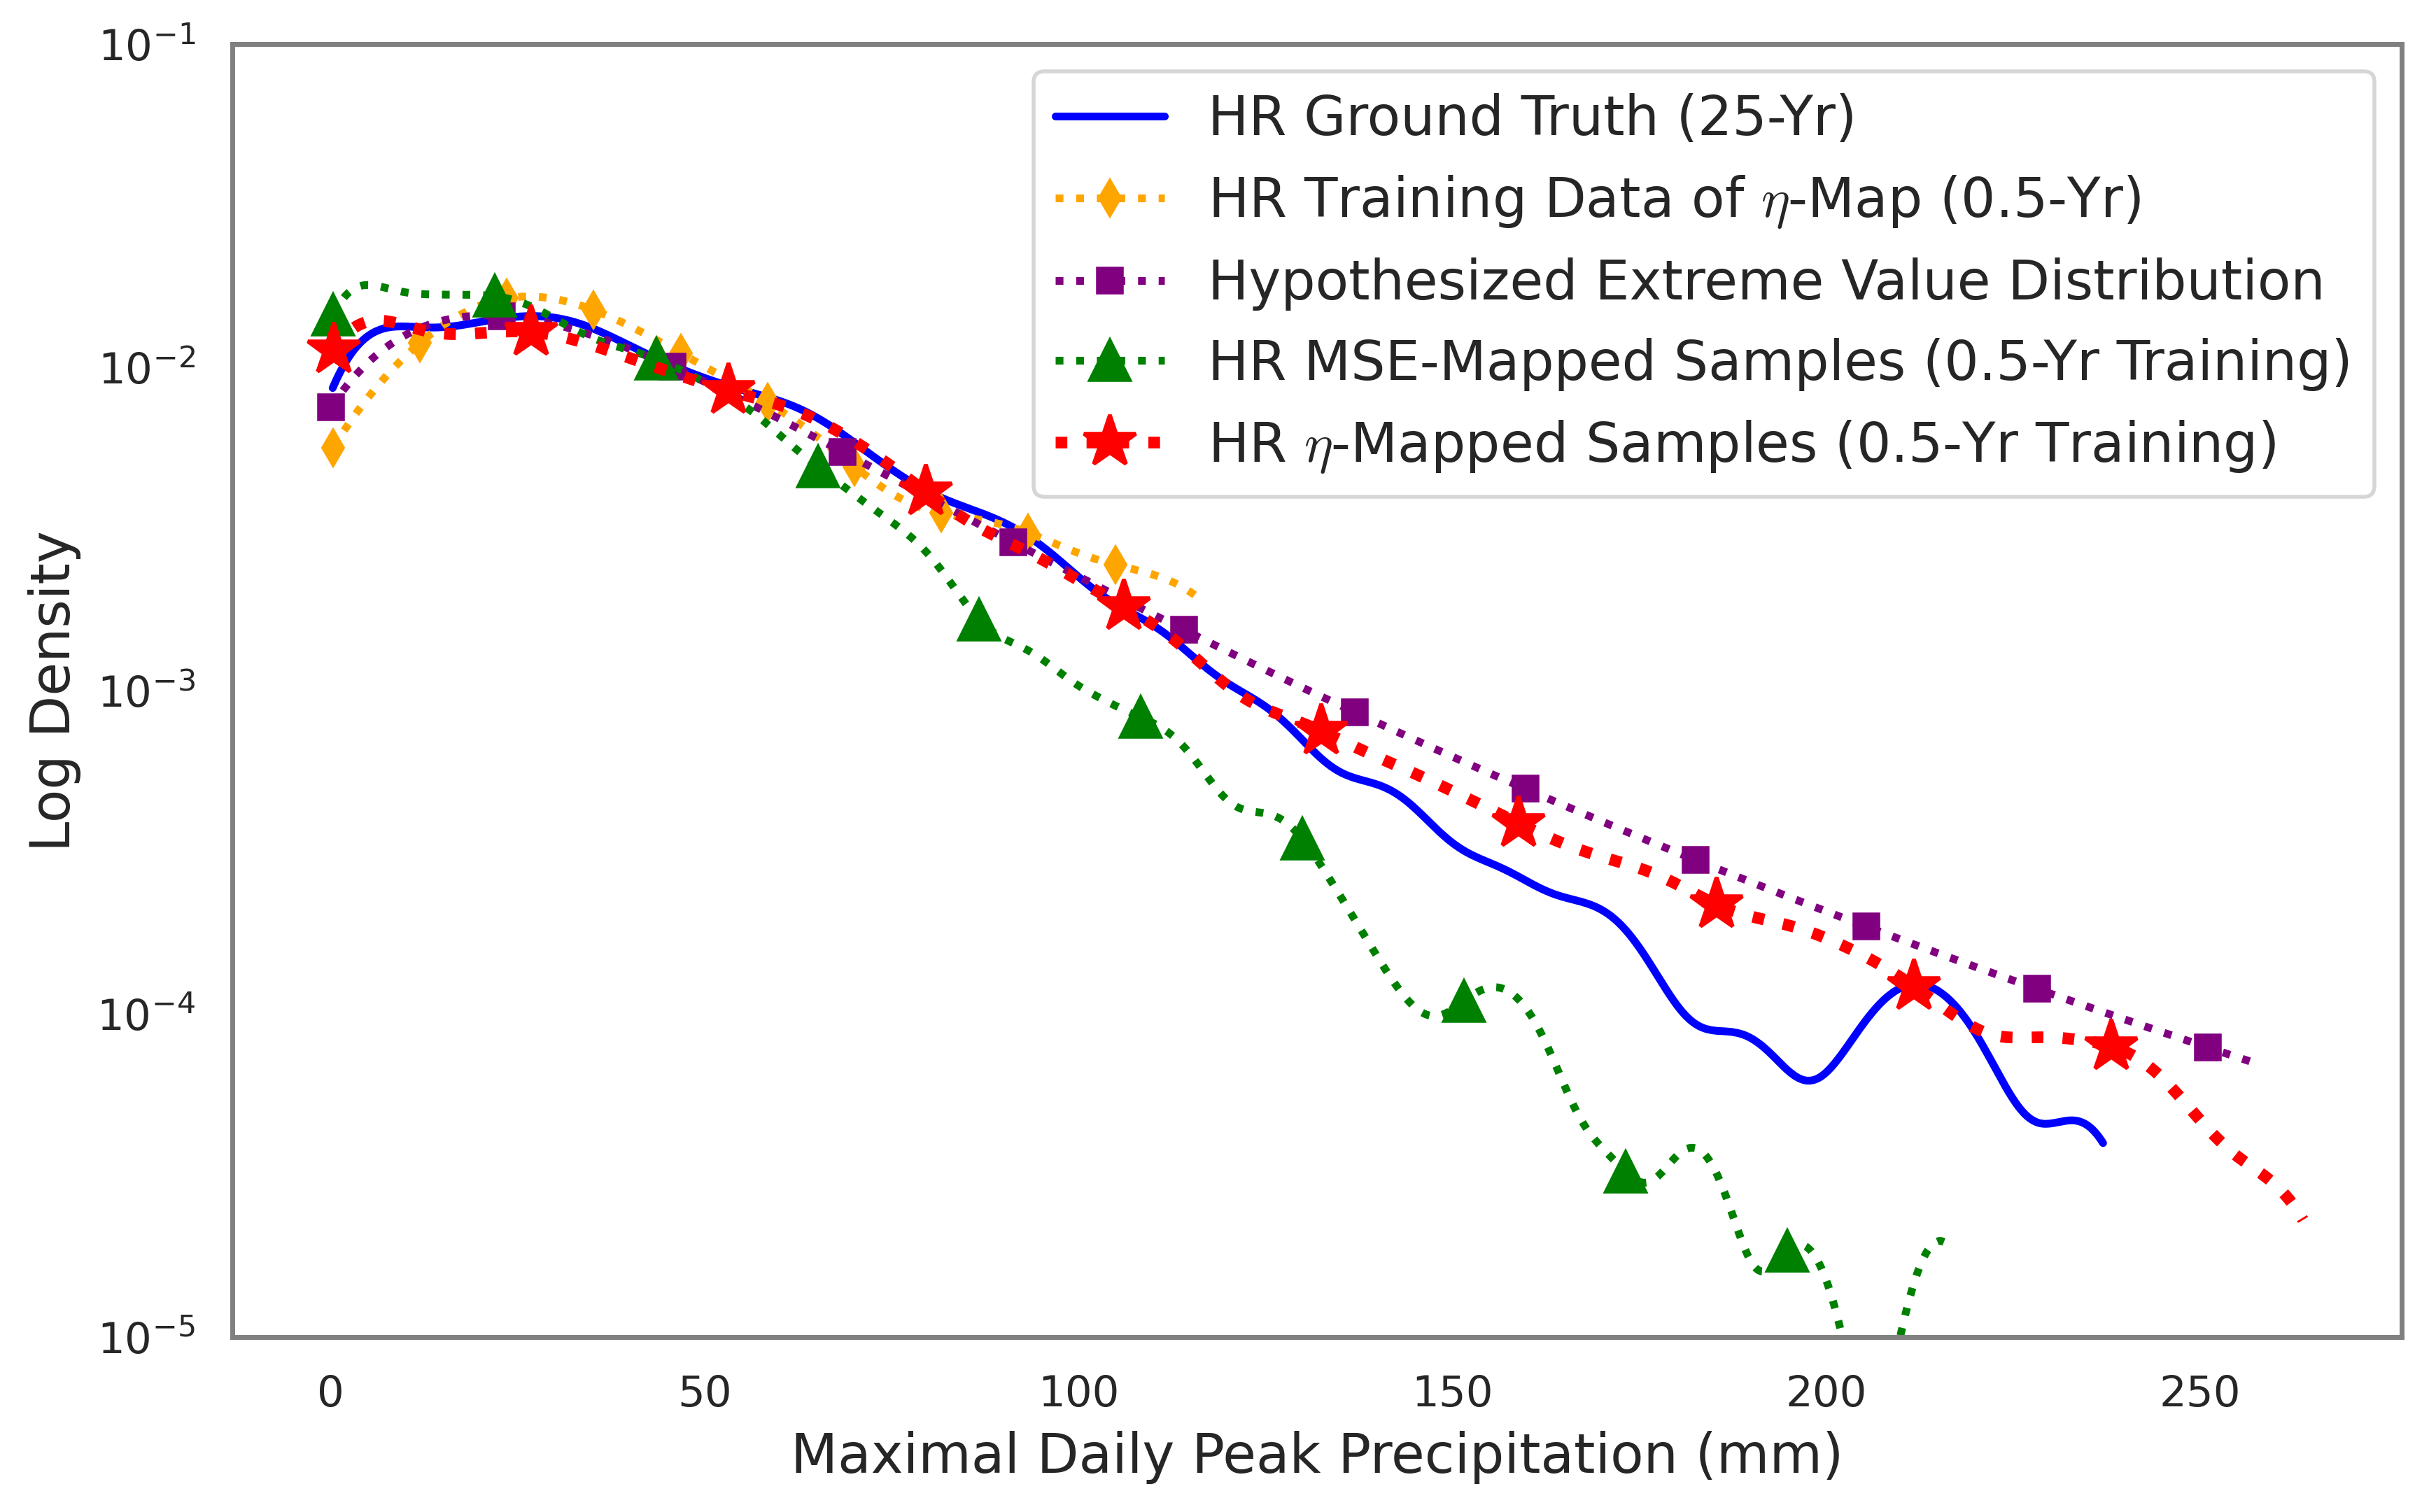

In [46]:
# full PDF comparison
max_values_eta = np.max(full_output_eta, axis=(1,2))
max_values_train = np.max(tp_trim_numpy[:train_size], axis=(1,2))
# max_values_eta = max_values_eta[max_values_eta < sorted_max_values[-1]]
# tail_values_eta = max_values_eta[max_values_eta > w1_tail_thresh]

y_eval_true, py_true, _ = get_data_pdf(data=torch.tensor(max_values), data_all=torch.tensor(max_values))
y_eval_mse, py_mse, _ = get_data_pdf(data=torch.tensor(max_values_mse), data_all=torch.tensor(max_values_mse))
y_eval_eta, py_eta, _ = get_data_pdf(data=torch.tensor(max_values_eta), data_all=torch.tensor(max_values_eta))
y_eval_train, py_train, _ = get_data_pdf(data=torch.tensor(max_values_train), data_all=torch.tensor(max_values_train))

# Plotting the two KDEs for comparison
plt.figure(figsize=(10, 6), dpi=400)

# Plot the PDFs
marker_every = 100
plt.plot(y_eval_true, py_true, label=r"HR Ground Truth (25-Yr)", color='blue', linestyle='-', linewidth=2) 
plt.plot(y_eval_train, py_train, label=r"HR Training Data of $\eta$-Map (0.5-Yr)", color='orange', linestyle=':', 
         marker='d', markevery=100, linewidth=2)
plt.plot(fit_results['x'], fit_results['pdf'], label="Hypothesized Extreme Value Distribution", color='purple', linestyle=':', 
         marker='s', markevery=800, linewidth=2)
plt.plot(y_eval_mse, py_mse, label=r"HR MSE-Mapped Samples (0.5-Yr Training)", color='green', linestyle=':', 
         marker='^', markevery=marker_every, linewidth=2, markersize=10)
plt.plot(y_eval_eta, py_eta, label=r"HR $\eta$-Mapped Samples (0.5-Yr Training)", color='red', linestyle=':', 
         marker='*', markersize=14, markevery=marker_every, linewidth=3)
# plt.hist(max_values, bins=40, density=True, alpha=0.3, color="gray", label=r"$\{y_i\}_{i=1}^{9044}$")

# plot the KDE truncated tails
# plt.plot(y_eval_true[y_eval_true > 150], py_true[y_eval_true > 150], label="25 Years True")
# plt.plot(y_eval_mse[y_eval_mse > 150], py_mse[y_eval_mse > 150], label="25 Years MSE", linestyle='-.')
# plt.plot(y_eval_eta[y_eval_eta > 150], py_eta[y_eval_eta > 150], label=fr"25 Years $\eta$", linestyle='--')

# Plot the tails
# plt.plot(y_tail_eval_true, py_tail_true, label="25 Years True Tail")
# plt.plot(y_tail_eval_mse, py_tail_mse, label="25 Years MSE Tail", linestyle='-.')
# plt.plot(y_tail_eval_eta, py_tail_eta, label=fr"25 Years $\eta$ Tail", linestyle='--')

# Add plot labels and title
plt.xlabel("Maximal Daily Peak Precipitation (mm)", fontsize=14)
plt.ylabel("Log Density", fontsize=14)
# plt.title("PDF of Regional Max Precipitation", fontsize=14)
plt.ylim(1e-5,1e-1)
plt.yscale('log')
plt.legend(prop={'size': 14})

In [47]:
# visualize_day = 1364
# time_str = str(tp.time.values[visualize_day])[:10]
# ds_field = tp_trim_ds_numpy[visualize_day]
# true_field = tp_trim_numpy[visualize_day]
# mse_field = full_output_mse[visualize_day]
# eta_field = full_output_eta[visualize_day]
# fig,axes = plot_nfields(ds_field, true_field, mse_field, eta_field, title_date=time_str, longitudes=tp.longitude.values, latitudes=tp.latitude.values, add_ylabel=False)

# Revision experiment: prior-misspecification sensitivity

This revision stress test quantifies how the eta map responds to prescribed tail laws. It supports the interpretation that eta learning is faithful to the supplied prior law $\nu_0$, not an oracle that corrects a misspecified prior.

Define perturbed reference quantiles
$$
Q_\alpha(q)=Q_{\rm true}(q)+\alpha\left(Q_{\rm GEVD}(q)-Q_{\rm true}(q)\right),\qquad q\in[\tau,1],
$$
with $\alpha\in\{-1,-0.5,0.5,1.5,2\}$. The endpoints $\alpha=0$ and $\alpha=1$ are omitted from the misspecified-tail training runs because they reproduce the empirical true-tail anchor and the nominal GEVD-tail anchor, respectively. The true and GEVD curves are still displayed as references in the plots.

For each misspecified $\alpha$, the notebook trains the eta map once if a cached checkpoint is missing, saves it under `WORK_DIR/models/precip-srcnn/misspec/`, then reloads the checkpoint for testing. The numerical table reports only full-field spatial metrics. Observable distributional discrepancy is shown visually by the testing PDF comparison against truth.


This section intentionally does not report conditional-mean, weighted-coverage, or Wasserstein distributional-error numerics for the misspecified-tail models. The reviewer-facing point is visible in the testing observable PDF: eta learning follows the prescribed tail, so misspecified priors can induce misspecified extremes. Physical fidelity is summarized by spatial RMSE plus the mean and standard deviation of per-field SSIM.


The following code constructs the perturbed reference quantiles and displays the prior-quantile comparison table. It does not save any table or figure.


In [48]:
from IPython.display import display
import pandas as pd
from revision_utils import empirical_quantiles, to_numpy

revision_alpha_values = [-1, -0.5, 0.5, 1.5, 2]
revision_alpha_marker_map = {
    alpha: marker
    for alpha, marker in zip(revision_alpha_values, ['o', 's', '^', 'D', 'v'])
}
revision_alpha_color_map = {
    alpha: color
    for alpha, color in zip(revision_alpha_values, ['tab:orange', 'tab:green', 'tab:red', 'tab:purple', 'tab:brown'])
}
revision_quantiles = quantiles if 'quantiles' in globals() else torch.linspace(tau, 1, num_w1_days)
revision_q_np = np.asarray(to_numpy(revision_quantiles), dtype=float)
revision_true_observable = np.max(tp_trim_numpy, axis=(1, 2))
revision_Q_true = empirical_quantiles(revision_true_observable, revision_q_np)
revision_Q_gevd = np.asarray([Qy(float(q)) for q in revision_q_np], dtype=float)
revision_Q_alpha = {
    alpha: revision_Q_true + alpha * (revision_Q_gevd - revision_Q_true)
    for alpha in revision_alpha_values
}

revision_prior_quantile_df = pd.DataFrame({
    'q': revision_q_np,
    'Q_true': revision_Q_true,
    'Q_GEVD': revision_Q_gevd,
    **{f'Q_alpha={alpha:g}': values for alpha, values in revision_Q_alpha.items()},
})

display(revision_prior_quantile_df.head())
display(revision_prior_quantile_df.tail())


,q,Q_true,Q_GEVD,Q_alpha=-1,Q_alpha=-0.5,Q_alpha=0.5,Q_alpha=1.5,Q_alpha=2
0,0.950000,106.220702,122.835698,89.605706,97.913204,114.528200,131.143196,139.450694
1,0.950143,106.497304,122.952758,90.041849,98.269576,114.725031,131.180485,139.408212
2,0.950287,106.676961,123.070124,90.283799,98.480380,114.873543,131.266705,139.463287
3,0.950430,106.714097,123.187897,90.240297,98.477197,114.950997,131.424797,139.661696
4,0.950573,106.728451,123.305980,90.150922,98.439686,115.017215,131.594744,139.883509


,q,Q_true,Q_GEVD,Q_alpha=-1,Q_alpha=-0.5,Q_alpha=0.5,Q_alpha=1.5,Q_alpha=2
345,0.999427,227.794521,250.317520,205.271522,216.533022,239.056021,261.579020,272.840519
346,0.999570,233.729424,252.142654,215.316194,224.522809,242.936039,261.349268,270.555883
347,0.999713,234.098937,254.029328,214.168545,224.133741,244.064132,263.994524,273.959719
348,0.999857,235.321087,255.979828,214.662345,224.991716,245.650457,266.309199,276.638569
349,1.000000,237.287674,258.000000,216.575348,226.931511,247.643837,268.356163,278.712326


The next plot shows $Q_{\rm true}$, $Q_{\rm GEVD}$, and the misspecified $Q_\alpha$ curves used as candidate reference laws. The misspecified tails use distinct colors and markers; the same alpha styles are reused in the testing observable PDF below. The defining formula is displayed inside the figure frame.


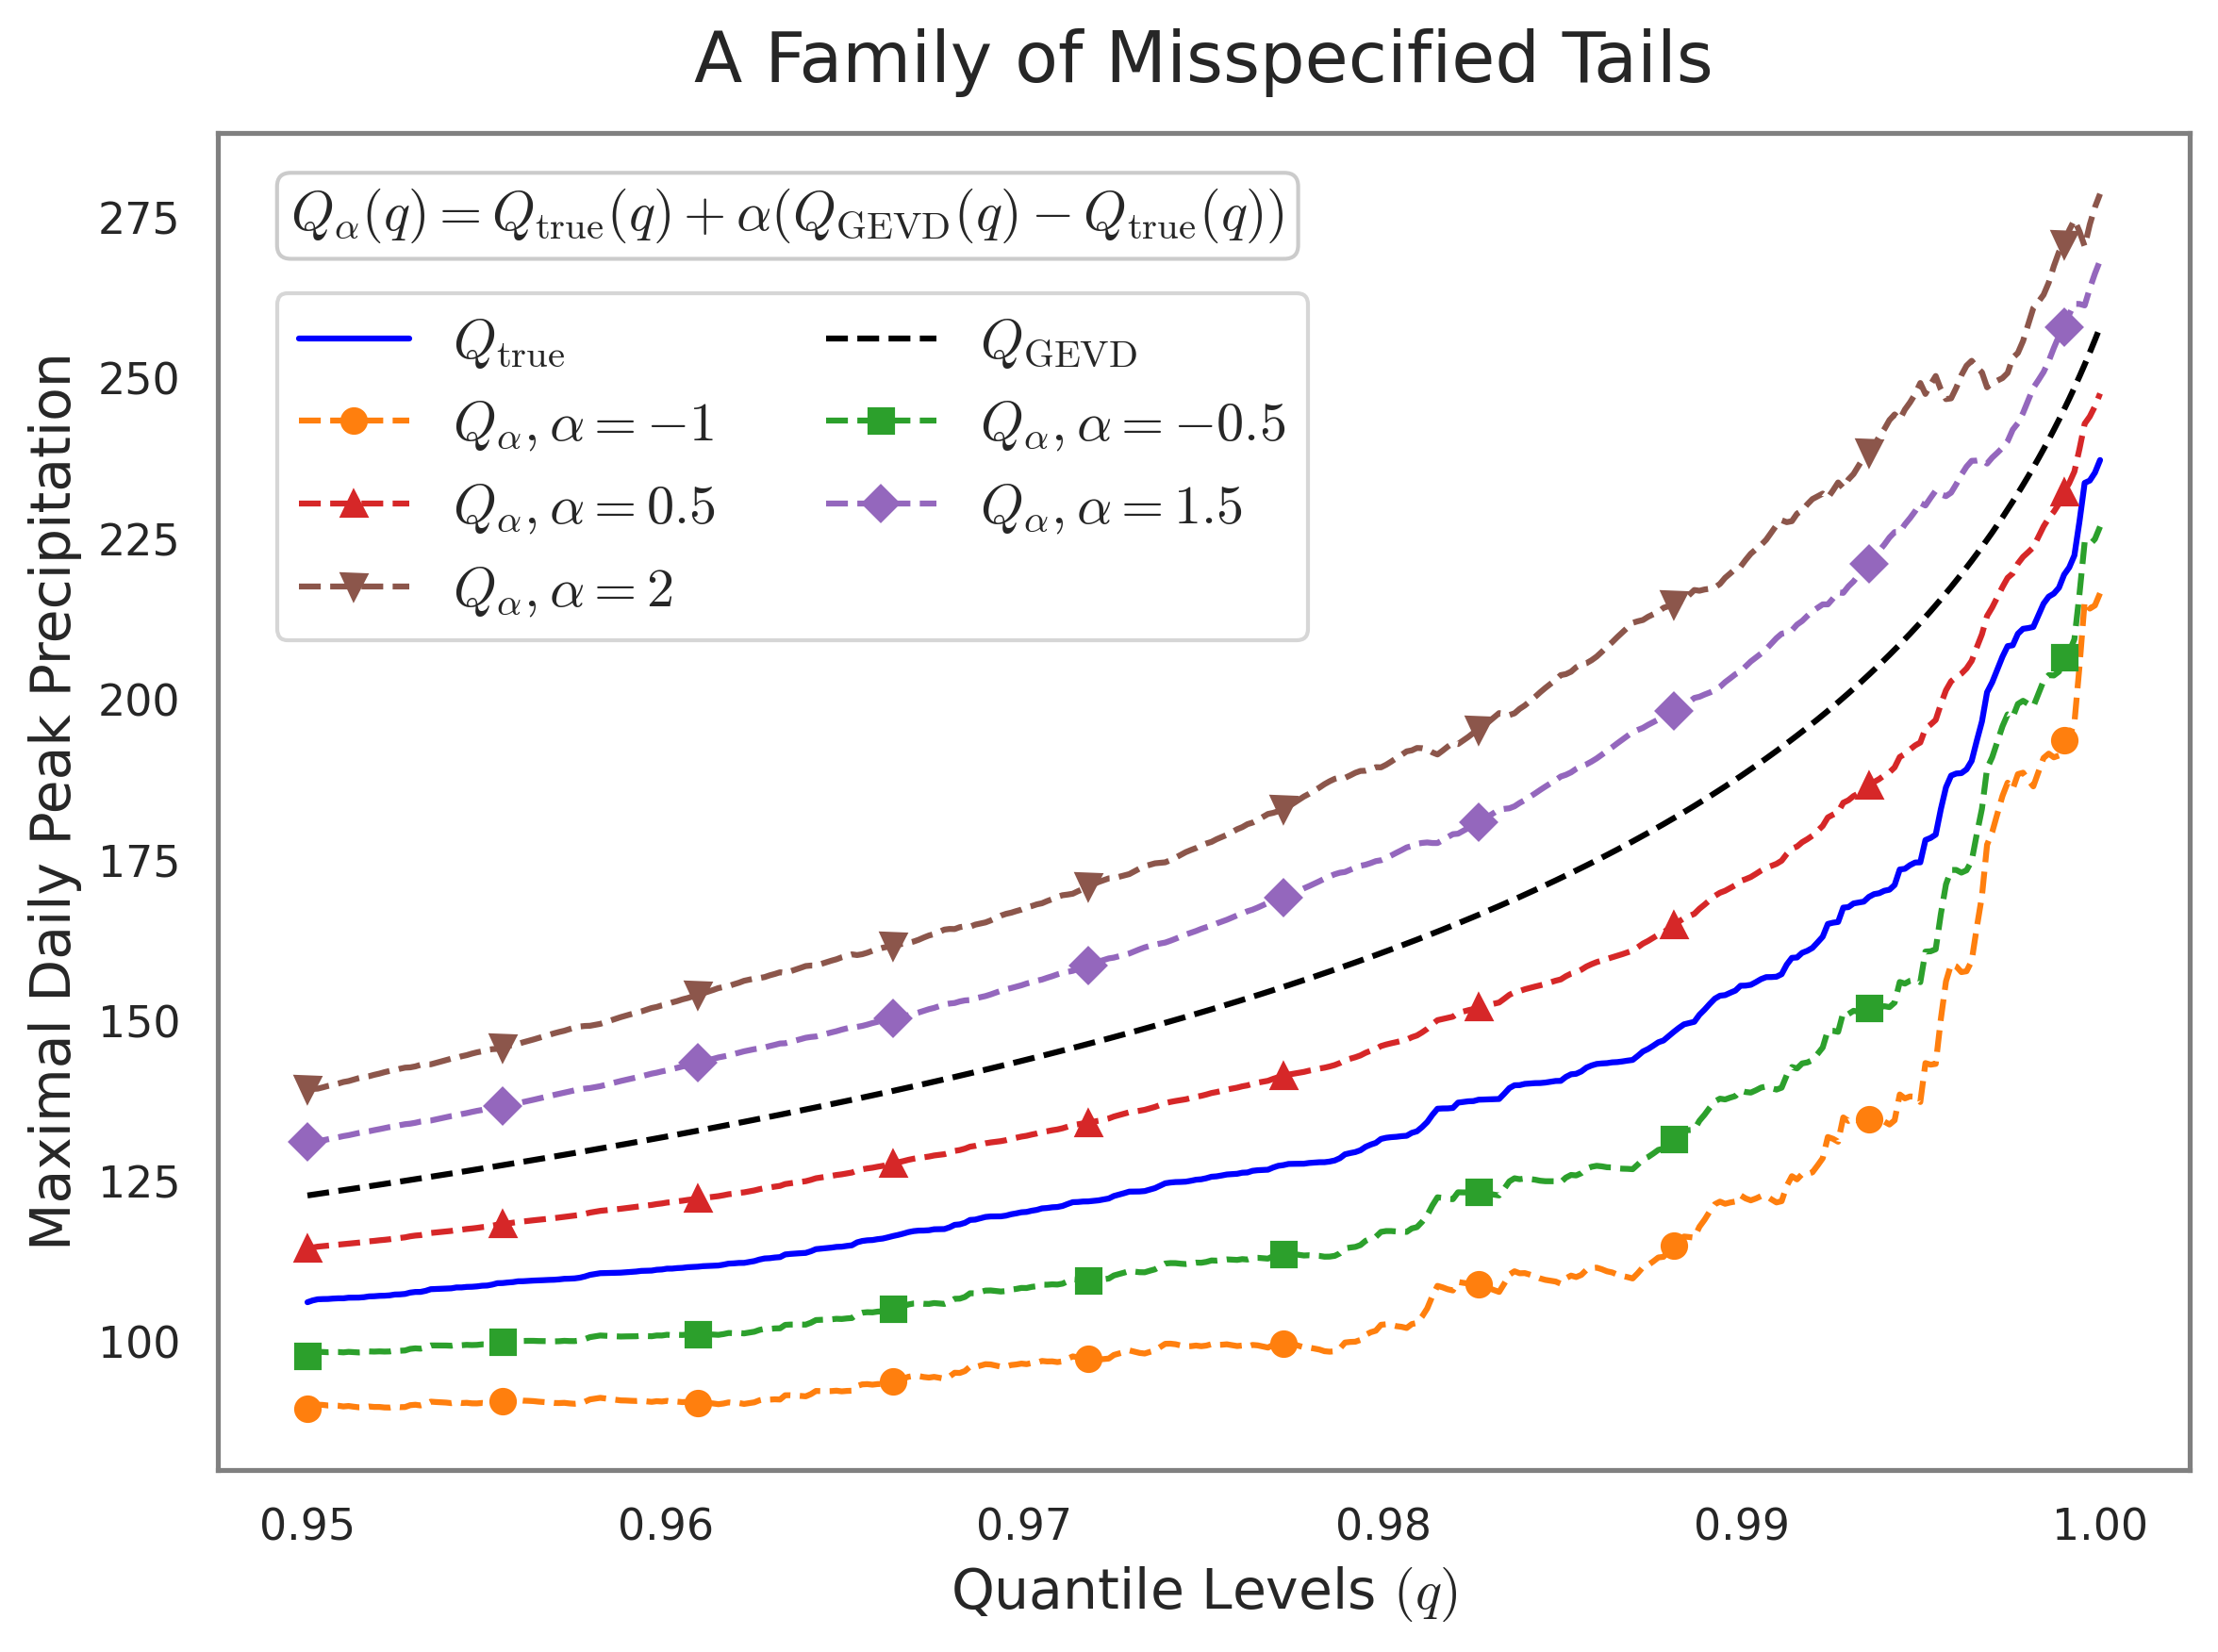

In [49]:
revision_formula_label = r'$Q_\alpha(q)=Q_{\rm true}(q)+\alpha(Q_{\rm GEVD}(q)-Q_{\rm true}(q))$'
fig, ax = plt.subplots(figsize=(8, 6), dpi=300)
ax.plot(revision_q_np, revision_Q_true, label=r'$Q_{\rm true}$', linewidth=1.5, color='blue')
ax.plot(revision_q_np, revision_Q_gevd, label=r'$Q_{\rm GEVD}$', linewidth=1.5, color='black', linestyle='--')
for alpha, values in revision_Q_alpha.items():
    marker = revision_alpha_marker_map.get(alpha, 'o')
    color = revision_alpha_color_map.get(alpha, None)
    ax.plot(
        revision_q_np,
        values,
        color=color,
        linestyle='--',
        linewidth=1.5,
        marker=marker,
        markersize=6,
        markevery=max(1, len(revision_q_np) // 9),
        label=rf'$Q_\alpha, \alpha={alpha:g}$',
    )
ax.text(
    0.037,
    0.96,
    revision_formula_label,
    transform=ax.transAxes,
    ha='left',
    va='top',
    fontsize=14,
    bbox=dict(boxstyle='round,pad=0.25', facecolor='white', edgecolor='0.6', alpha=0.5),
)
ax.set_xlabel(r'Quantile Levels $(q)$', fontsize=14)
ax.set_ylabel('Maximal Daily Peak Precipitation', fontsize=14)
ax.set_title('A Family of Misspecified Tails', fontsize=18, pad=13)
legend_handles, legend_labels = ax.get_legend_handles_labels()
legend_ncol = 2
legend_nrow = (len(legend_handles) + legend_ncol - 1) // legend_ncol
legend_order = [
    row * legend_ncol + col
    for col in range(legend_ncol)
    for row in range(legend_nrow)
    if row * legend_ncol + col < len(legend_handles)
]
ax.legend(
    [legend_handles[i] for i in legend_order],
    [legend_labels[i] for i in legend_order],
    fontsize=14,
    ncol=legend_ncol,
    loc='upper left',
    bbox_to_anchor=(0.03, 0.88),
    borderaxespad=0.0,
)
fig.tight_layout()
plt.show()


The following code trains or loads the misspecified-tail eta maps and evaluates only spatial field metrics. The cache path is

`WORK_DIR/models/precip-srcnn/misspec/`.

The alpha tag used in each filename replaces a minus sign by `m` and a decimal point by `p`, so $\alpha=-0.5$ becomes `alpha_m0p5` and $\alpha=0.5$ becomes `alpha_0p5`.

For testing fields $u_j$ and predictions $\widehat u_j$, this cell reports
$$
{\rm RMSE}_{\rm grid}=\left[\frac{1}{Nn_g}\sum_{j=1}^N\sum_{i=1}^{n_g}(\widehat u_j^{(i)}-u_j^{(i)})^2\right]^{1/2},
$$
plus the mean and standard deviation of per-field SSIM values. Existing `train_model_eta` checkpoints are loaded and tested directly; missing checkpoints are trained once with the notebook's `train_model_eta`, saved, then reloaded for testing. The original `train_model_eta` function above prints progress summaries every 25 epochs and always prints the final epoch; the progress task itself still advances every epoch.


In [50]:
from copy import deepcopy
from pathlib import Path
from models import SRCNN
from revision_utils import precip_spatial_metrics, predict_field_array

revision_misspec_model_dir = Path(WORK_DIR) / 'models' / 'precip-srcnn' / 'misspec'
revision_misspec_model_dir.mkdir(parents=True, exist_ok=True)
revision_data_range = float(np.nanmax(tp_trim_numpy) - np.nanmin(tp_trim_numpy))
revision_misspec_observable_by_alpha = {}
revision_misspec_metric_rows = []
revision_misspec_cache_rows = []


def revision_alpha_tag(alpha):
    alpha_text = f'{float(alpha):g}'
    return alpha_text.replace('-', 'm').replace('.', 'p')


def revision_misspec_model_path(alpha):
    alpha_tag = revision_alpha_tag(alpha)
    year_tag = revision_alpha_tag(num_years)
    filename = f'srcnn-eta-misspec-train_model_eta-alpha_{alpha_tag}-{year_tag}yr-{ds_fact}ds-{int(w1_tail_thresh)}tail-{omega}omega.pth'
    return revision_misspec_model_dir / filename


def make_revision_srcnn_model():
    model = SRCNN(hidden_dim=64, num_blocks=3, scale_factor=ds_fact)
    model = nn.DataParallel(model)
    return model.to(device)


def load_revision_misspec_model(alpha):
    model_path = revision_misspec_model_path(alpha)
    model = make_revision_srcnn_model()
    state_dict = torch.load(model_path, map_location=device)
    model.load_state_dict(state_dict)
    model.to(device)
    model.eval()
    return model



RUN_MISSING_MISSPEC_TRAINING = True

for alpha in revision_alpha_values:
    model_path = revision_misspec_model_path(alpha)
    alpha_tag = revision_alpha_tag(alpha)
    status = 'loaded_existing'

    if not model_path.exists():
        if not RUN_MISSING_MISSPEC_TRAINING:
            print(f'Missing {model_path}; set RUN_MISSING_MISSPEC_TRAINING=True to train it.')
            revision_misspec_cache_rows.append({
                'alpha': alpha,
                'alpha_tag': alpha_tag,
                'model_filename': model_path.name,
                'model_path': str(model_path),
                'status': 'missing_not_trained',
            })
            continue

        print(f'Training misspecified-tail eta map with train_model_eta for alpha={alpha:g}')
        model_alpha_train = deepcopy(model_mse).to(device)
        optimizer = optim.Adam(model_alpha_train.parameters(), lr=3e-4)
        w1_truemax_alpha = torch.tensor(revision_Q_alpha[alpha], dtype=torch.float32).to(device)
        model_alpha_train, loss_dict_alpha = train_model_eta(
            model_alpha_train,
            test_loader,
            seed,
            num_epochs,
            mse_input,
            mse_target,
            w1_loss,
            w1_truemax_alpha,
            w1_truedays,
            lambd_,
            omega,
            varying_days,
            save_checkpoint=True,
            save_path=str(model_path),
            scheduler=None,
            clip_gradient=False,
            device=device,
        )
        status = 'trained_saved_then_loaded'
        del model_alpha_train, loss_dict_alpha
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    print(f'Testing cached misspecified-tail model for alpha={alpha:g}: {model_path.name}')
    model_alpha_eval = load_revision_misspec_model(alpha)
    output_alpha = predict_field_array(model_alpha_eval, test_loader, device=device)
    spatial = precip_spatial_metrics(output_alpha, tp_trim_numpy, data_range=revision_data_range)
    revision_misspec_observable_by_alpha[alpha] = np.max(output_alpha, axis=(1, 2))
    revision_misspec_metric_rows.append({
        'alpha': alpha,
        'alpha_tag': alpha_tag,
        'N_samples': int(output_alpha.shape[0]),
        'RMSE_grid': spatial['RMSE_grid'],
        'mean_SSIM': spatial['mean_SSIM'],
        'std_SSIM': spatial['std_SSIM'],
        'model_filename': model_path.name,
        'status': status,
    })
    revision_misspec_cache_rows.append({
        'alpha': alpha,
        'alpha_tag': alpha_tag,
        'model_filename': model_path.name,
        'model_path': str(model_path),
        'status': status,
    })
    del model_alpha_eval, output_alpha
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

revision_misspec_spatial_metrics_df = pd.DataFrame(revision_misspec_metric_rows)
revision_misspec_model_cache_df = pd.DataFrame(revision_misspec_cache_rows)

display(revision_misspec_spatial_metrics_df)


Testing cached misspecified-tail model for alpha=-1: srcnn-eta-misspec-train_model_eta-alpha_m1-0p5yr-10ds-122tail-1omega.pth
Testing cached misspecified-tail model for alpha=-0.5: srcnn-eta-misspec-train_model_eta-alpha_m0p5-0p5yr-10ds-122tail-1omega.pth
Testing cached misspecified-tail model for alpha=0.5: srcnn-eta-misspec-train_model_eta-alpha_0p5-0p5yr-10ds-122tail-1omega.pth
Testing cached misspecified-tail model for alpha=1.5: srcnn-eta-misspec-train_model_eta-alpha_1p5-0p5yr-10ds-122tail-1omega.pth
Testing cached misspecified-tail model for alpha=2: srcnn-eta-misspec-train_model_eta-alpha_2-0p5yr-10ds-122tail-1omega.pth


,alpha,alpha_tag,N_samples,RMSE_grid,mean_SSIM,std_SSIM,model_filename,status
0,-1.0,m1,9044,2.926038,0.947280,0.043792,srcnn-eta-misspec-train_model_eta-alpha_m1-0p5...,loaded_existing
1,-0.5,m0p5,9044,2.967890,0.946510,0.044193,srcnn-eta-misspec-train_model_eta-alpha_m0p5-0...,loaded_existing
2,0.5,0p5,9044,3.193944,0.944542,0.045382,srcnn-eta-misspec-train_model_eta-alpha_0p5-0p...,loaded_existing
3,1.5,1p5,9044,3.423614,0.940689,0.048021,srcnn-eta-misspec-train_model_eta-alpha_1p5-0p...,loaded_existing
4,2.0,2,9044,3.527282,0.941217,0.047701,srcnn-eta-misspec-train_model_eta-alpha_2-0p5y...,loaded_existing


The following figure plots the testing observable PDFs for the cached misspecified-tail eta models against the true HR observable law. For each field,
$$
y_j=g(u_j)=\max_i u_j^{(i)},
\qquad
\widehat y_{\alpha,j}=g(\widehat u_{\alpha,j})=\max_i \widehat u_{\alpha,j}^{(i)}.
$$
The KDE curves are fit with the notebook's `get_data_pdf` helper. The MSE PDF is intentionally omitted; distributional discrepancy is assessed visually from the truth-vs-misspecified curves.


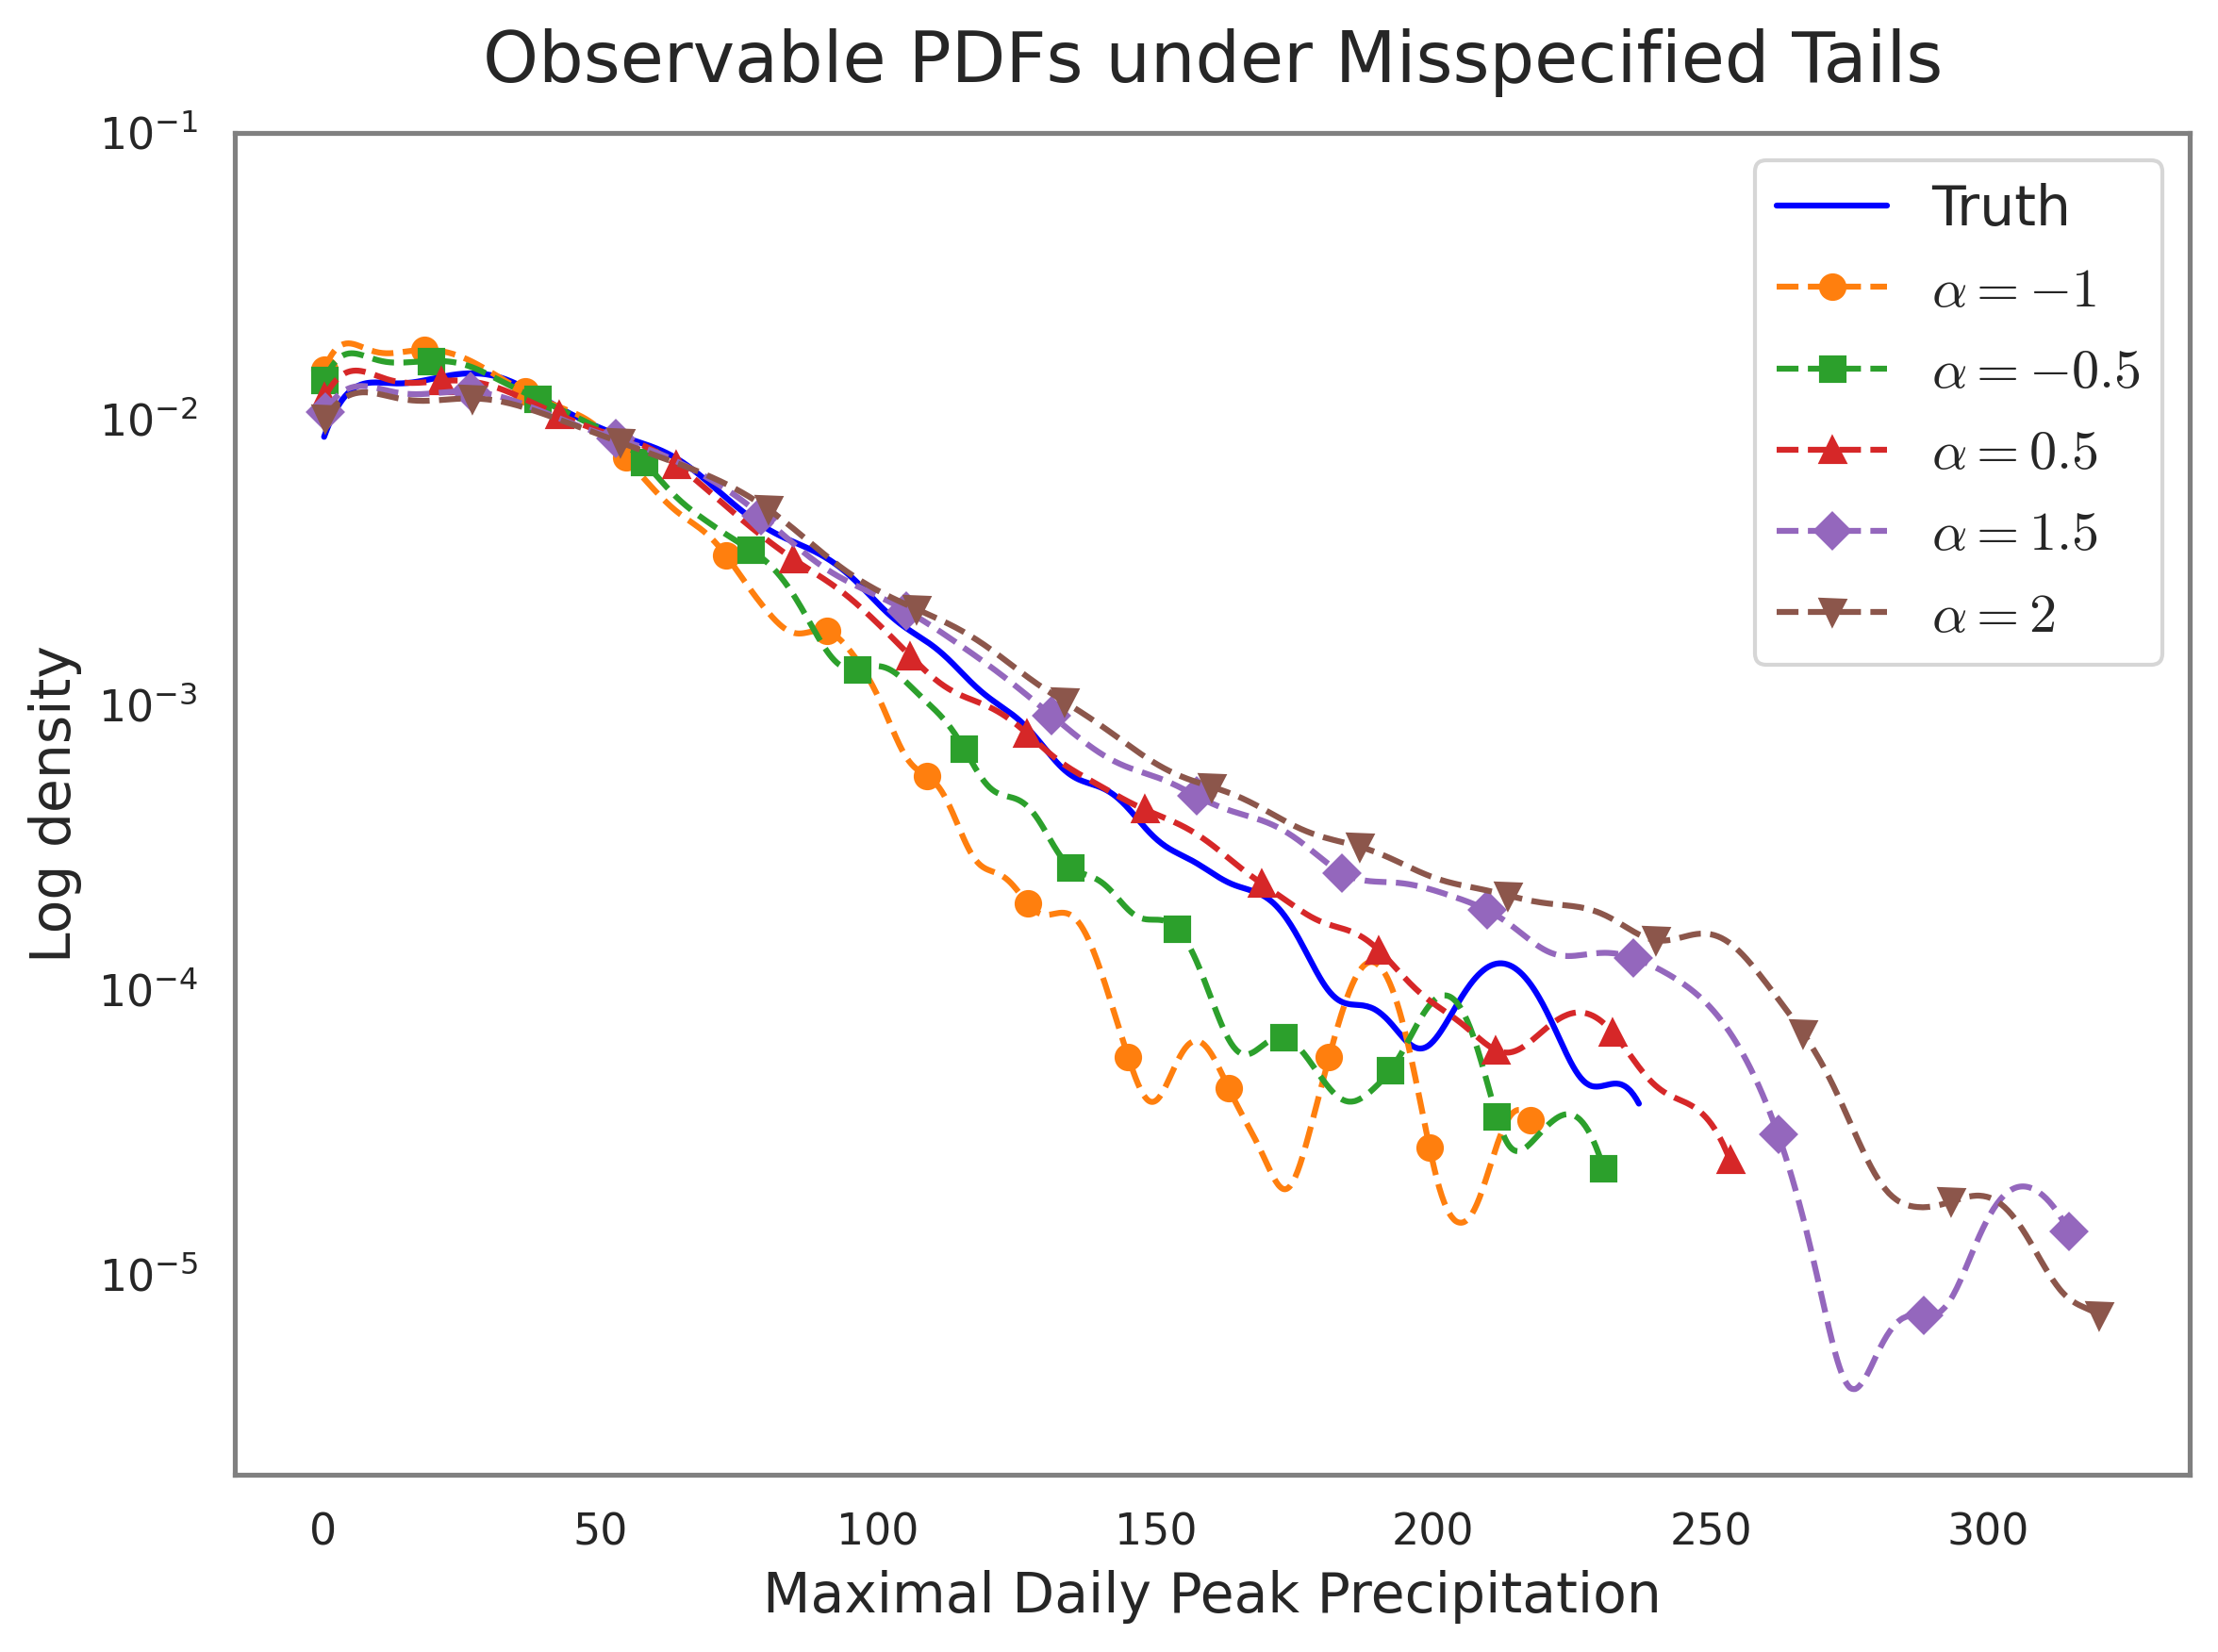

In [51]:
if revision_misspec_observable_by_alpha:
    revision_pdf_support_values = np.concatenate([
        revision_true_observable,
        *[values for values in revision_misspec_observable_by_alpha.values()],
    ])
    revision_pdf_support_tensor = torch.tensor(revision_pdf_support_values, dtype=torch.float32)
    y_eval_true_pdf, py_true_pdf, _ = get_data_pdf(
        data=torch.tensor(revision_true_observable, dtype=torch.float32),
        data_all=revision_true_observable,
    )

    fig, ax = plt.subplots(figsize=(8, 6), dpi=300)
    y_eval_true_pdf = np.asarray(y_eval_true_pdf)
    py_true_pdf = np.asarray(py_true_pdf)
    truth_visible = np.isfinite(y_eval_true_pdf) & np.isfinite(py_true_pdf) & (py_true_pdf > 0)
    ax.plot(y_eval_true_pdf[truth_visible], py_true_pdf[truth_visible], label=r'Truth', linewidth=1.5, color='blue')

    for alpha in revision_alpha_values:
        if alpha not in revision_misspec_observable_by_alpha:
            continue
        y_eval_alpha_pdf, py_alpha_pdf, _ = get_data_pdf(
            data=torch.tensor(revision_misspec_observable_by_alpha[alpha], dtype=torch.float32),
            data_all=torch.tensor(revision_misspec_observable_by_alpha[alpha], dtype=torch.float32),
        )
        y_eval_alpha_pdf = np.asarray(y_eval_alpha_pdf)
        py_alpha_pdf = np.asarray(py_alpha_pdf)
        positive = np.isfinite(y_eval_alpha_pdf) & np.isfinite(py_alpha_pdf) & (py_alpha_pdf > 0)
        ax.plot(
            y_eval_alpha_pdf[positive],
            py_alpha_pdf[positive],
            color=revision_alpha_color_map.get(alpha, None),
            linestyle='--',
            linewidth=1.5,
            marker=revision_alpha_marker_map.get(alpha, 'o'),
            markersize=6,
            markevery=max(1, int(np.sum(positive)) // 12),
            label=rf'$\alpha={alpha:g}$',
        )

    ax.set_xlabel('Maximal Daily Peak Precipitation', fontsize=14)
    ax.set_ylabel('Log density', fontsize=14)
    ax.set_title(r'Observable PDFs under Misspecified Tails', fontsize=18, pad=13)
    ax.set_yscale('log')
    # ax.grid(alpha=0.3)
    ax.set_ylim(2e-6,1e-1)
    ax.legend(fontsize=14, ncol=1)
    fig.tight_layout()
    plt.show()
else:
    print('No cached misspecified-tail model outputs are available for PDF plotting.')


The checkpoint-cache table below is shown for reproducibility. It lists which alpha-specific checkpoint file was loaded or trained-and-saved. No metric table or figure is saved by this revision block.


In [52]:
if len(revision_misspec_model_cache_df) > 0:
    display(revision_misspec_model_cache_df)
else:
    print(f'No misspecified-tail checkpoint rows are available. Cache directory: {revision_misspec_model_dir}')


,alpha,alpha_tag,model_filename,model_path,status
0,-1.0,m1,srcnn-eta-misspec-train_model_eta-alpha_m1-0p5...,/path/to/eta/...,loaded_existing
1,-0.5,m0p5,srcnn-eta-misspec-train_model_eta-alpha_m0p5-0...,/path/to/eta/...,loaded_existing
2,0.5,0p5,srcnn-eta-misspec-train_model_eta-alpha_0p5-0p...,/path/to/eta/...,loaded_existing
3,1.5,1p5,srcnn-eta-misspec-train_model_eta-alpha_1p5-0p...,/path/to/eta/...,loaded_existing
4,2.0,2,srcnn-eta-misspec-train_model_eta-alpha_2-0p5y...,/path/to/eta/...,loaded_existing


η-learning is faithful to the prescribed prior law. Therefore, if $\nu_0$ is misspecified, the generated extremes can also be misspecified. This is useful for stress testing hypothesized tail laws, but it is not an oracle for recovering the unknown true tail.

# Revision documentation notes

This notebook corresponds to the paper's hypothesized-GEVD/heavier-tail precipitation experiment. The revision section added above displays perturbed prior quantiles, a train-once/load-later cache table for misspecified-tail eta checkpoints, spatial-fidelity metrics, and a truth-vs-misspecified testing observable PDF. Misspecified-tail models are trained with the existing `train_model_eta` function and saved under `WORK_DIR/models/precip-srcnn/misspec/` using alpha tags such as `alpha_m0p5` and `alpha_0p5`; no revision figures or tables are saved. Existing pre-revision cells, saved figures, models, samples, and experiment logic were not modified.
